<a href="https://colab.research.google.com/github/sungfeliks/Lightweight-Mixture-of-Experts-with-Knowledge-Distillation-Vision-Language-Model/blob/main/08_external_validation_generalization_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 08 — External Validation and Generalization Analysis

This notebook performs external validation of the final CBIS-DDSM-trained
student models on independent mammography datasets.

Primary external cohorts:
1. CMMD — Expanded lesion-side primary cohort
2. INbreast — Strict breast-time-point-consistent cohort

Sensitivity-analysis cohorts:
1. CMMD — Strict two-image cohort
2. INbreast — Broad breast-time-point-consistent cohort

Models:
- MobileNetV3-Small Baseline
- MobileNetV3-Small Sparse Top-2 MoE
- MobileNetV3-Small Sparse Top-2 MoE + Knowledge Distillation

Important evaluation policy:
- No model retraining
- No fine-tuning on external data
- No threshold re-optimization
- No hyperparameter selection using external labels
- No external-domain calibration
- Internal CBIS-DDSM thresholds are frozen before external evaluation

## **PREPARATION**

### **Mount Google Drive**

In [1]:
from google.colab import drive

drive.mount(
    "/content/drive"
)

Mounted at /content/drive


### **Install DICOM Dependencies**

In [2]:
!pip install -q \
    pydicom \
    pylibjpeg \
    pylibjpeg-libjpeg \
    pylibjpeg-openjpeg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 90.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 81.8 MB/s eta 0:00:00


### **Imports**

In [3]:
import gc
import json
import math
import random
import shutil
import time
import warnings
import zipfile

from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pydicom
import torch
import torch.nn as nn
import torch.nn.functional as F

from PIL import Image

from pydicom.pixel_data_handlers.util import (
    apply_modality_lut,
    apply_voi_lut,
)

from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

from torch.utils.data import (
    DataLoader,
    Dataset,
)

from torchvision.models import (
    mobilenet_v3_small,
)

warnings.filterwarnings(
    "ignore"
)

print(
    "PyTorch:",
    torch.__version__,
)

print(
    "CUDA available:",
    torch.cuda.is_available(),
)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0),
    )

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


### **Reproducibility**

In [4]:
SEED = 42


def set_global_seed(
    seed: int = 42,
):
    random.seed(
        seed
    )

    np.random.seed(
        seed
    )

    torch.manual_seed(
        seed
    )

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(
            seed
        )


set_global_seed(
    SEED
)


DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

USE_AMP = (
    DEVICE.type
    == "cuda"
)

print(
    "Seed:",
    SEED,
)

print(
    "Device:",
    DEVICE,
)

print(
    "AMP:",
    USE_AMP,
)

Seed: 42
Device: cuda
AMP: True


### **Project Paths**

In [5]:
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Research"
)

PROCESSED_ROOT = (
    PROJECT_ROOT
    / "processed"
)

EXTERNAL_PROCESSED_ROOT = (
    PROCESSED_ROOT
    / "external"
)

EXTERNAL_OUTPUT_ROOT = (
    PROJECT_ROOT
    / "outputs"
    / "external_validation"
)

EXTERNAL_OUTPUT_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)


CMMD_PRIMARY_CSV = (
    EXTERNAL_PROCESSED_ROOT
    / "cmmd"
    / "cmmd_external_primary.csv"
)

CMMD_STRICT_CSV = (
    EXTERNAL_PROCESSED_ROOT
    / "cmmd"
    / "cmmd_external_strict_two_image.csv"
)

CMMD_MANIFEST_PATH = (
    EXTERNAL_PROCESSED_ROOT
    / "cmmd"
    / "cmmd_external_primary_manifest.json"
)


INBREAST_STRICT_CSV = (
    EXTERNAL_PROCESSED_ROOT
    / "inbreast"
    / "inbreast_external_strict.csv"
)

INBREAST_BROAD_CSV = (
    EXTERNAL_PROCESSED_ROOT
    / "inbreast"
    / "inbreast_external_broad.csv"
)

INBREAST_MANIFEST_PATH = (
    EXTERNAL_PROCESSED_ROOT
    / "inbreast"
    / "inbreast_external_manifest.json"
)


CMMD_ZIP_PATH = (
    PROJECT_ROOT
    / "datasets"
    / "cmmd.zip"
)

INBREAST_ZIP_PATH = (
    PROJECT_ROOT
    / "datasets"
    / "inbreast_2012.zip"
)


required_paths = [
    CMMD_PRIMARY_CSV,
    CMMD_STRICT_CSV,
    INBREAST_STRICT_CSV,
    INBREAST_BROAD_CSV,
    CMMD_ZIP_PATH,
    INBREAST_ZIP_PATH,
]


for required_path in required_paths:
    print(
        f"{'FOUND' if required_path.exists() else 'MISSING':7s}",
        required_path,
    )


assert all(
    path.exists()
    for path in required_paths
), (
    "One or more required Notebook 07 "
    "outputs/source archives are missing."
)

FOUND   /content/drive/MyDrive/Research/processed/external/cmmd/cmmd_external_primary.csv
FOUND   /content/drive/MyDrive/Research/processed/external/cmmd/cmmd_external_strict_two_image.csv
FOUND   /content/drive/MyDrive/Research/processed/external/inbreast/inbreast_external_strict.csv
FOUND   /content/drive/MyDrive/Research/processed/external/inbreast/inbreast_external_broad.csv
FOUND   /content/drive/MyDrive/Research/datasets/cmmd.zip
FOUND   /content/drive/MyDrive/Research/datasets/inbreast_2012.zip


## **LOAD AND VERIFY FROZEN EXTERNAL COHORTS**

### **Load Cohort CSVs**

In [6]:
cmmd_primary_df = pd.read_csv(
    CMMD_PRIMARY_CSV
)

cmmd_strict_df = pd.read_csv(
    CMMD_STRICT_CSV
)

inbreast_strict_df = pd.read_csv(
    INBREAST_STRICT_CSV
)

inbreast_broad_df = pd.read_csv(
    INBREAST_BROAD_CSV
)


print(
    "CMMD primary :",
    cmmd_primary_df.shape,
)

print(
    "CMMD strict  :",
    cmmd_strict_df.shape,
)

print(
    "INbreast strict:",
    inbreast_strict_df.shape,
)

print(
    "INbreast broad :",
    inbreast_broad_df.shape,
)

CMMD primary : (2046, 33)
CMMD strict  : (1886, 33)
INbreast strict: (341, 34)
INbreast broad : (383, 34)


### **Inspect Final Schemas**

In [7]:
external_dataframes = {
    "CMMD primary": (
        cmmd_primary_df
    ),
    "CMMD strict": (
        cmmd_strict_df
    ),
    "INbreast strict": (
        inbreast_strict_df
    ),
    "INbreast broad": (
        inbreast_broad_df
    ),
}


for (
    cohort_name,
    dataframe,
) in external_dataframes.items():

    print(
        "\n"
        + "=" * 80
    )

    print(
        cohort_name
    )

    print(
        "=" * 80
    )

    print(
        "Rows:",
        len(dataframe),
    )

    print(
        "\nColumns:"
    )

    print(
        dataframe.columns.tolist()
    )

    print(
        "\nFirst row:"
    )

    display(
        dataframe.head(1)
    )


CMMD primary
Rows: 2046

Columns:
['image_path', 'relative_path', 'patient_id', 'image_id', 'dataset_name', 'dataset_subset', 'cohort_origin', 'label', 'label_name', 'label_source', 'label_scope', 'lesion_laterality', 'derived_image_laterality', 'laterality_source', 'laterality_mapping_method', 'view', 'view_index', 'source_image_slot', 'Age', 'Abnormality', 'Subtype', 'Method_crop', 'source_format', 'height', 'width', 'image_dtype', 'file_size_bytes', 'file_sha256', 'pixel_sha256', 'source_archive_path', 'source_metadata_path', 'include_primary', 'exclusion_reason']

First row:


,image_path,relative_path,patient_id,image_id,dataset_name,dataset_subset,cohort_origin,label,label_name,label_source,...,height,width,image_dtype,file_size_bytes,file_sha256,pixel_sha256,source_archive_path,source_metadata_path,include_primary,exclusion_reason
0,/content/external_datasets/cmmd/CMMD/Cancer/D1...,Cancer/D1-0001_1-1.png,D1-0001,D1-0001_1-1,CMMD,CMMD1_D1_expanded_lesion_side_primary,D1_two_image_direct,0,Benign,description.csv:Classification,...,1280,471,uint8,213916,079e2e1d7af61b15ba6c61bbd43cef1569f171280272a3...,d67372d54f0385a7daff0d8d789d94f422bf16d4eaf2cf...,/content/drive/MyDrive/Research/datasets/cmmd.zip,/content/external_datasets/cmmd/CMMD/descripti...,True,NaN



CMMD strict
Rows: 1886

Columns:
['image_path', 'relative_path', 'patient_id', 'image_id', 'dataset_name', 'dataset_subset', 'cohort_origin', 'label', 'label_name', 'label_source', 'label_scope', 'lesion_laterality', 'derived_image_laterality', 'laterality_source', 'laterality_mapping_method', 'view', 'view_index', 'source_image_slot', 'Age', 'Abnormality', 'Subtype', 'Method_crop', 'source_format', 'height', 'width', 'image_dtype', 'file_size_bytes', 'file_sha256', 'pixel_sha256', 'source_archive_path', 'source_metadata_path', 'include_primary', 'exclusion_reason']

First row:


,image_path,relative_path,patient_id,image_id,dataset_name,dataset_subset,cohort_origin,label,label_name,label_source,...,height,width,image_dtype,file_size_bytes,file_sha256,pixel_sha256,source_archive_path,source_metadata_path,include_primary,exclusion_reason
0,/content/external_datasets/cmmd/CMMD/Cancer/D1...,Cancer/D1-0033_1-2.png,D1-0033,D1-0033_1-2,CMMD,CMMD1_D1_expanded_lesion_side_primary,D1_two_image_direct,0,Benign,description.csv:Classification,...,1280,386,uint8,291848,570bcfda19dcdaf864b4fc2f2c2cd3ab307baf3a14e059...,3820c0e9a12adbdb3b26cd57fa92616db2073be4b394e4...,/content/drive/MyDrive/Research/datasets/cmmd.zip,/content/external_datasets/cmmd/CMMD/descripti...,True,NaN



INbreast strict
Rows: 341

Columns:
['image_path', 'relative_path', 'patient_id', 'anatomical_breast_id', 'timepoint_id', 'breast_timepoint_id', 'image_id', 'dataset_name', 'dataset_subset', 'label', 'label_name', 'label_source', 'label_scope', 'birads', 'acr', 'laterality', 'view', 'acquisition_date', 'source_format', 'pixel_height', 'pixel_width', 'pixel_dtype', 'file_size_bytes', 'file_sha256', 'pixel_sha256', 'study_instance_uid', 'series_instance_uid', 'sop_instance_uid', 'manufacturer', 'manufacturer_model_name', 'source_archive_path', 'source_metadata_path', 'include_external', 'exclusion_reason']

First row:


,image_path,relative_path,patient_id,anatomical_breast_id,timepoint_id,breast_timepoint_id,image_id,dataset_name,dataset_subset,label,...,pixel_sha256,study_instance_uid,series_instance_uid,sop_instance_uid,manufacturer,manufacturer_model_name,source_archive_path,source_metadata_path,include_external,exclusion_reason
0,/content/external_datasets/inbreast/INbreast R...,AllDICOMs/20588020_024ee3569b2605dc_MG_L_CC_AN...,024ee3569b2605dc,024ee3569b2605dc_L,024ee3569b2605dc_200902,024ee3569b2605dc_200902_L,20588020,INbreast,INbreast_strict_BIRADS_1_2_vs_5_6_breast_timep...,0,...,beb2568259334012f2ea219aace0f2ea4112bc5c0a2e67...,1.3.6.1.4.1.9590.100.1.1.377984764411663747003...,1.3.6.1.4.1.9590.100.1.1.370777078511695763322...,1.3.6.1.4.1.9590.100.1.1.172124667210923804500...,NaN,NaN,/content/drive/MyDrive/Research/datasets/inbre...,/content/external_datasets/inbreast/INbreast R...,True,NaN



INbreast broad
Rows: 383

Columns:
['image_path', 'relative_path', 'patient_id', 'anatomical_breast_id', 'timepoint_id', 'breast_timepoint_id', 'image_id', 'dataset_name', 'dataset_subset', 'label', 'label_name', 'label_source', 'label_scope', 'birads', 'acr', 'laterality', 'view', 'acquisition_date', 'source_format', 'pixel_height', 'pixel_width', 'pixel_dtype', 'file_size_bytes', 'file_sha256', 'pixel_sha256', 'study_instance_uid', 'series_instance_uid', 'sop_instance_uid', 'manufacturer', 'manufacturer_model_name', 'source_archive_path', 'source_metadata_path', 'include_external', 'exclusion_reason']

First row:


,image_path,relative_path,patient_id,anatomical_breast_id,timepoint_id,breast_timepoint_id,image_id,dataset_name,dataset_subset,label,...,pixel_sha256,study_instance_uid,series_instance_uid,sop_instance_uid,manufacturer,manufacturer_model_name,source_archive_path,source_metadata_path,include_external,exclusion_reason
0,/content/external_datasets/inbreast/INbreast R...,AllDICOMs/20588020_024ee3569b2605dc_MG_L_CC_AN...,024ee3569b2605dc,024ee3569b2605dc_L,024ee3569b2605dc_200902,024ee3569b2605dc_200902_L,20588020,INbreast,INbreast_broad_BIRADS_1_2_vs_4a_6_breast_timep...,0,...,beb2568259334012f2ea219aace0f2ea4112bc5c0a2e67...,1.3.6.1.4.1.9590.100.1.1.377984764411663747003...,1.3.6.1.4.1.9590.100.1.1.370777078511695763322...,1.3.6.1.4.1.9590.100.1.1.172124667210923804500...,NaN,NaN,/content/drive/MyDrive/Research/datasets/inbre...,/content/external_datasets/inbreast/INbreast R...,True,NaN


### **Verify Frozen Cohort Sizes**

In [8]:
EXPECTED_COHORT_SIZES = {
    "cmmd_primary": 2046,
    "cmmd_strict": 1886,
    "inbreast_strict": 341,
    "inbreast_broad": 383,
}


assert (
    len(
        cmmd_primary_df
    )
    == EXPECTED_COHORT_SIZES[
        "cmmd_primary"
    ]
)

assert (
    len(
        cmmd_strict_df
    )
    == EXPECTED_COHORT_SIZES[
        "cmmd_strict"
    ]
)

assert (
    len(
        inbreast_strict_df
    )
    == EXPECTED_COHORT_SIZES[
        "inbreast_strict"
    ]
)

assert (
    len(
        inbreast_broad_df
    )
    == EXPECTED_COHORT_SIZES[
        "inbreast_broad"
    ]
)


print(
    "All frozen external cohort "
    "sizes match Notebook 07."
)

All frozen external cohort sizes match Notebook 07.


## **FREEZE EXTERNAL EVALUATION PROTOCOL**

### **Frozen Internal Thresholds**

In [9]:
FROZEN_THRESHOLDS = {
    "Baseline": (
        0.5166015625
    ),
    "MoE": (
        0.3496335447
    ),
    "MoE+KD": (
        0.2529684305
    ),
}


INTERNAL_REFERENCE_METRICS = {
    "Baseline": {
        "roc_auc": 0.7716,
        "average_precision": 0.7435,
    },
    "MoE": {
        "roc_auc": 0.7524,
        "average_precision": 0.7034,
    },
    "MoE+KD": {
        "roc_auc": 0.7489,
        "average_precision": 0.6928,
    },
}


for model_name in (
    FROZEN_THRESHOLDS
):
    print(
        f"{model_name:10s} | "
        f"Threshold = "
        f"{FROZEN_THRESHOLDS[model_name]:.10f} | "
        f"Internal AUC = "
        f"{INTERNAL_REFERENCE_METRICS[model_name]['roc_auc']:.4f}"
    )

Baseline   | Threshold = 0.5166015625 | Internal AUC = 0.7716
MoE        | Threshold = 0.3496335447 | Internal AUC = 0.7524
MoE+KD     | Threshold = 0.2529684305 | Internal AUC = 0.7489


### **Pre-register the Analysis Roles**

In [10]:
PRIMARY_COHORTS = {
    "CMMD": (
        "cmmd_primary"
    ),
    "INbreast": (
        "inbreast_strict"
    ),
}


SENSITIVITY_COHORTS = {
    "CMMD strict two-image": (
        "cmmd_strict"
    ),
    "INbreast broad": (
        "inbreast_broad"
    ),
}


BOOTSTRAP_REPLICATES = 2000
BOOTSTRAP_SEED = 42


print(
    "Primary external evaluation:"
)

for (
    dataset_name,
    cohort_name,
) in PRIMARY_COHORTS.items():
    print(
        " -",
        dataset_name,
        "->",
        cohort_name,
    )


print(
    "\nSensitivity analyses:"
)

for (
    dataset_name,
    cohort_name,
) in SENSITIVITY_COHORTS.items():
    print(
        " -",
        dataset_name,
        "->",
        cohort_name,
    )


print(
    "\nBootstrap replicates:",
    BOOTSTRAP_REPLICATES,
)

print(
    "Bootstrap unit: patient"
)

Primary external evaluation:
 - CMMD -> cmmd_primary
 - INbreast -> inbreast_strict

Sensitivity analyses:
 - CMMD strict two-image -> cmmd_strict
 - INbreast broad -> inbreast_broad

Bootstrap replicates: 2000
Bootstrap unit: patient


## **LOCATE FROZEN MODEL CHECKPOINTS**

### **Checkpoint Discovery Utility**

In [11]:
MODEL_OUTPUT_ROOT = (
    PROJECT_ROOT
    / "outputs"
)


def discover_checkpoint(
    include_terms,
    exclude_terms=None,
):
    if exclude_terms is None:
        exclude_terms = []

    candidates = []

    for path in (
        MODEL_OUTPUT_ROOT
        .rglob("*.pt")
    ):
        path_string = str(
            path
        ).lower()

        filename = (
            path.name.lower()
        )

        if "best" not in filename:
            continue

        if not all(
            term.lower()
            in path_string
            for term
            in include_terms
        ):
            continue

        if any(
            term.lower()
            in path_string
            for term
            in exclude_terms
        ):
            continue

        candidates.append(
            path
        )

    return sorted(
        candidates
    )

### **Discover Three Final Checkpoints**

In [12]:
baseline_candidates = (
    discover_checkpoint(
        include_terms=[
            "mobilenetv3",
            "small",
            "baseline",
        ],
    )
)


moe_candidates = (
    discover_checkpoint(
        include_terms=[
            "mobilenetv3",
            "small",
            "sparse",
            "top2",
            "moe",
        ],
        exclude_terms=[
            "kd",
        ],
    )
)


kd_candidates = (
    discover_checkpoint(
        include_terms=[
            "mobilenetv3",
            "small",
            "sparse",
            "top2",
            "moe",
            "kd",
        ],
    )
)


print(
    "BASELINE CANDIDATES"
)

for path in baseline_candidates:
    print(
        " -",
        path,
    )


print(
    "\nMOE CANDIDATES"
)

for path in moe_candidates:
    print(
        " -",
        path,
    )


print(
    "\nKD CANDIDATES"
)

for path in kd_candidates:
    print(
        " -",
        path,
    )

BASELINE CANDIDATES
 - /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_baseline/checkpoints/mobilenetv3_small_baseline_best.pt

MOE CANDIDATES
 - /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe/checkpoints/mobilenetv3_small_sparse_top2_moe_best.pt

KD CANDIDATES
 - /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe_kd/checkpoints/mobilenetv3_small_sparse_top2_moe_kd_best.pt


### **Resolve Final Checkpoint Paths**

In [13]:
assert (
    len(
        baseline_candidates
    )
    == 1
), (
    "Expected exactly one baseline "
    "best checkpoint."
)


assert (
    len(
        moe_candidates
    )
    == 1
), (
    "Expected exactly one non-KD "
    "MoE best checkpoint."
)


assert (
    len(
        kd_candidates
    )
    == 1
), (
    "Expected exactly one KD "
    "best checkpoint."
)


BASELINE_CHECKPOINT_PATH = (
    baseline_candidates[0]
)

MOE_CHECKPOINT_PATH = (
    moe_candidates[0]
)

KD_CHECKPOINT_PATH = (
    kd_candidates[0]
)


FINAL_CHECKPOINTS = {
    "Baseline": (
        BASELINE_CHECKPOINT_PATH
    ),
    "MoE": (
        MOE_CHECKPOINT_PATH
    ),
    "MoE+KD": (
        KD_CHECKPOINT_PATH
    ),
}


print(
    "Frozen checkpoints:"
)

for (
    model_name,
    checkpoint_path,
) in FINAL_CHECKPOINTS.items():

    print(
        f"{model_name:10s}: "
        f"{checkpoint_path}"
    )

Frozen checkpoints:
Baseline  : /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_baseline/checkpoints/mobilenetv3_small_baseline_best.pt
MoE       : /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe/checkpoints/mobilenetv3_small_sparse_top2_moe_best.pt
MoE+KD    : /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe_kd/checkpoints/mobilenetv3_small_sparse_top2_moe_kd_best.pt


### **Inspect Checkpoint Structure Before Reconstructing Models**

In [14]:
def load_checkpoint_cpu(
    checkpoint_path,
):
    try:
        checkpoint = torch.load(
            checkpoint_path,
            map_location="cpu",
            weights_only=False,
        )

    except TypeError:
        checkpoint = torch.load(
            checkpoint_path,
            map_location="cpu",
        )

    return checkpoint


def identify_state_dict(
    checkpoint,
):
    if not isinstance(
        checkpoint,
        dict,
    ):
        return None, None

    candidate_keys = [
        "model_state_dict",
        "state_dict",
        "model",
        "student_state_dict",
    ]

    for key in candidate_keys:
        if (
            key in checkpoint
            and isinstance(
                checkpoint[key],
                dict,
            )
        ):
            return (
                key,
                checkpoint[key],
            )

    if all(
        isinstance(
            value,
            torch.Tensor,
        )
        for value
        in checkpoint.values()
    ):
        return (
            "<checkpoint itself>",
            checkpoint,
        )

    return (
        None,
        None,
    )


checkpoint_inspection = {}


for (
    model_name,
    checkpoint_path,
) in FINAL_CHECKPOINTS.items():

    print(
        "\n"
        + "=" * 80
    )

    print(
        model_name
    )

    print(
        "=" * 80
    )

    checkpoint = (
        load_checkpoint_cpu(
            checkpoint_path
        )
    )

    if isinstance(
        checkpoint,
        dict,
    ):
        print(
            "Top-level keys:"
        )

        print(
            list(
                checkpoint.keys()
            )
        )

    (
        state_dict_key,
        state_dict,
    ) = identify_state_dict(
        checkpoint
    )

    print(
        "\nState-dict key:",
        state_dict_key,
    )

    if state_dict is not None:
        print(
            "Number of tensors:",
            len(
                state_dict
            ),
        )

        print(
            "\nFirst 20 state keys:"
        )

        for key in list(
            state_dict.keys()
        )[:20]:
            print(
                " ",
                key,
                tuple(
                    state_dict[
                        key
                    ].shape
                ),
            )

    metadata_preview = {}

    if isinstance(
        checkpoint,
        dict,
    ):
        for key in [
            "epoch",
            "best_val_auc",
            "val_auc",
            "threshold",
            "model_name",
            "architecture",
            "config",
        ]:
            if key in checkpoint:
                value = checkpoint[
                    key
                ]

                if not isinstance(
                    value,
                    dict,
                ):
                    metadata_preview[
                        key
                    ] = value

    print(
        "\nMetadata preview:"
    )

    print(
        metadata_preview
    )

    checkpoint_inspection[
        model_name
    ] = {
        "checkpoint": (
            checkpoint
        ),
        "state_dict_key": (
            state_dict_key
        ),
        "state_dict": (
            state_dict
        ),
    }


Baseline
Top-level keys:
['epoch', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'scaler_state_dict', 'train_metrics', 'val_metrics', 'best_val_auc', 'feature_dim', 'image_height', 'image_width', 'threshold', 'training_stage']

State-dict key: model_state_dict
Number of tensors: 242

First 20 state keys:
  features.0.0.weight (16, 3, 3, 3)
  features.0.1.weight (16,)
  features.0.1.bias (16,)
  features.0.1.running_mean (16,)
  features.0.1.running_var (16,)
  features.0.1.num_batches_tracked ()
  features.1.block.0.0.weight (16, 1, 3, 3)
  features.1.block.0.1.weight (16,)
  features.1.block.0.1.bias (16,)
  features.1.block.0.1.running_mean (16,)
  features.1.block.0.1.running_var (16,)
  features.1.block.0.1.num_batches_tracked ()
  features.1.block.1.fc1.weight (8, 16, 1, 1)
  features.1.block.1.fc1.bias (8,)
  features.1.block.1.fc2.weight (16, 8, 1, 1)
  features.1.block.1.fc2.bias (16,)
  features.1.block.2.0.weight (16, 16, 1, 1)
  features.1.block.2.1.we

## **EXTERNAL IMAGE LOADING AND EXACT STUDENT PREPROCESSING**

### **Additional Imports and Preprocessing Constants**

In [15]:
import io


STUDENT_IMAGE_HEIGHT = 512
STUDENT_IMAGE_WIDTH = 320


IMAGENET_MEAN = np.asarray(
    [0.485, 0.456, 0.406],
    dtype=np.float32,
).reshape(
    1,
    1,
    3,
)


IMAGENET_STD = np.asarray(
    [0.229, 0.224, 0.225],
    dtype=np.float32,
).reshape(
    1,
    1,
    3,
)


print(
    "Student external input size:",
    (
        STUDENT_IMAGE_HEIGHT,
        STUDENT_IMAGE_WIDTH,
    ),
)

print(
    "ImageNet mean:",
    IMAGENET_MEAN.reshape(-1),
)

print(
    "ImageNet std:",
    IMAGENET_STD.reshape(-1),
)

Student external input size: (512, 320)
ImageNet mean: [0.485 0.456 0.406]
ImageNet std: [0.229 0.224 0.225]


### **Verify Sensitivity Cohorts Are Subsets of Inference Cohorts**

In [16]:
cmmd_primary_keys = set(
    cmmd_primary_df[
        "relative_path"
    ].astype(str)
)

cmmd_strict_keys = set(
    cmmd_strict_df[
        "relative_path"
    ].astype(str)
)


inbreast_broad_keys = set(
    inbreast_broad_df[
        "relative_path"
    ].astype(str)
)

inbreast_strict_keys = set(
    inbreast_strict_df[
        "relative_path"
    ].astype(str)
)


assert (
    cmmd_strict_keys
    .issubset(
        cmmd_primary_keys
    )
)

assert (
    inbreast_strict_keys
    .issubset(
        inbreast_broad_keys
    )
)


print(
    "CMMD strict subset of primary:",
    len(
        cmmd_strict_keys
    ),
    "/",
    len(
        cmmd_primary_keys
    ),
)

print(
    "INbreast strict subset of broad:",
    len(
        inbreast_strict_keys
    ),
    "/",
    len(
        inbreast_broad_keys
    ),
)

print(
    "\nInference therefore only needs:",
    len(
        cmmd_primary_df
    )
    + len(
        inbreast_broad_df
    ),
    "unique external images per model."
)

CMMD strict subset of primary: 1886 / 2046
INbreast strict subset of broad: 341 / 383

Inference therefore only needs: 2429 unique external images per model.


### **Verify Labels Are Unchanged in Overlapping Images**

In [17]:
def verify_overlap_labels(
    parent_df,
    subset_df,
    dataset_name,
):
    parent_labels = (
        parent_df[
            [
                "relative_path",
                "label",
            ]
        ]
        .drop_duplicates(
            subset="relative_path"
        )
        .set_index(
            "relative_path"
        )[
            "label"
        ]
    )

    subset_labels = (
        subset_df[
            [
                "relative_path",
                "label",
            ]
        ]
        .drop_duplicates(
            subset="relative_path"
        )
        .set_index(
            "relative_path"
        )[
            "label"
        ]
    )

    parent_for_subset = (
        parent_labels.loc[
            subset_labels.index
        ]
    )

    matches = (
        parent_for_subset
        .astype(int)
        .equals(
            subset_labels
            .astype(int)
        )
    )

    print(
        dataset_name,
        "overlap labels identical:",
        matches,
    )

    assert matches


verify_overlap_labels(
    cmmd_primary_df,
    cmmd_strict_df,
    "CMMD",
)

verify_overlap_labels(
    inbreast_broad_df,
    inbreast_strict_df,
    "INbreast",
)

CMMD overlap labels identical: True
INbreast overlap labels identical: True


### **Verify ZIP Member Mappings**

In [18]:
CMMD_ARCHIVE_PREFIX = (
    "CMMD/"
)

INBREAST_ARCHIVE_PREFIX = (
    "INbreast Release 1.0/"
)


with zipfile.ZipFile(
    CMMD_ZIP_PATH,
    "r",
) as archive:

    cmmd_archive_members = set(
        archive.namelist()
    )


with zipfile.ZipFile(
    INBREAST_ZIP_PATH,
    "r",
) as archive:

    inbreast_archive_members = set(
        archive.namelist()
    )


def cmmd_archive_member(
    relative_path,
):
    return (
        CMMD_ARCHIVE_PREFIX
        + str(
            relative_path
        ).replace(
            "\\",
            "/",
        )
    )


def inbreast_archive_member(
    relative_path,
):
    return (
        INBREAST_ARCHIVE_PREFIX
        + str(
            relative_path
        ).replace(
            "\\",
            "/",
        )
    )


cmmd_missing_members = [
    relative_path
    for relative_path
    in cmmd_primary_df[
        "relative_path"
    ].astype(str)
    if (
        cmmd_archive_member(
            relative_path
        )
        not in cmmd_archive_members
    )
]


inbreast_missing_members = [
    relative_path
    for relative_path
    in inbreast_broad_df[
        "relative_path"
    ].astype(str)
    if (
        inbreast_archive_member(
            relative_path
        )
        not in inbreast_archive_members
    )
]


print(
    "Missing CMMD archive members:",
    len(
        cmmd_missing_members
    ),
)

print(
    "Missing INbreast archive members:",
    len(
        inbreast_missing_members
    ),
)


assert (
    len(
        cmmd_missing_members
    )
    == 0
)

assert (
    len(
        inbreast_missing_members
    )
    == 0
)

Missing CMMD archive members: 0
Missing INbreast archive members: 0


### **Dataset-independent Student Pre-processing**

In [19]:
def student_preprocess_rgb(
    image_rgb,
):
    image_rgb = cv2.resize(
        image_rgb,
        (
            STUDENT_IMAGE_WIDTH,
            STUDENT_IMAGE_HEIGHT,
        ),
        interpolation=cv2.INTER_LINEAR,
    )

    image = image_rgb.astype(
        np.float32
    )

    image_min = float(
        image.min()
    )

    image_max = float(
        image.max()
    )

    image = (
        image
        - image_min
    ) / (
        image_max
        - image_min
        + 1e-8
    )

    display_image = (
        image.copy()
    )

    image = (
        image
        - IMAGENET_MEAN
    ) / IMAGENET_STD

    image = np.transpose(
        image,
        (
            2,
            0,
            1,
        ),
    )

    image = (
        np.ascontiguousarray(
            image
        )
    )

    tensor = (
        torch
        .from_numpy(
            image
        )
        .float()
    )

    return (
        tensor,
        display_image,
    )

### **CMMD PNG Decoder**

In [20]:
def decode_cmmd_png(
    binary_data,
):
    image = (
        Image.open(
            io.BytesIO(
                binary_data
            )
        )
        .convert(
            "RGB"
        )
    )

    image = np.asarray(
        image
    )

    return image

### **INbreast DICOM Decoder**

In [21]:
def decode_inbreast_dicom(
    binary_data,
):
    dicom = pydicom.dcmread(
        io.BytesIO(
            binary_data
        )
    )

    pixel_array = (
        dicom.pixel_array
    )

    try:
        pixel_array = (
            apply_modality_lut(
                pixel_array,
                dicom,
            )
        )
    except Exception:
        pass

    pixel_array = (
        np.asarray(
            pixel_array,
            dtype=np.float32,
        )
    )

    photometric = str(
        getattr(
            dicom,
            "PhotometricInterpretation",
            "",
        )
    ).upper()


    if (
        photometric
        == "MONOCHROME1"
    ):
        pixel_min = float(
            pixel_array.min()
        )

        pixel_max = float(
            pixel_array.max()
        )

        pixel_array = (
            pixel_max
            + pixel_min
            - pixel_array
        )


    if (
        pixel_array.ndim
        != 2
    ):
        pixel_array = (
            np.squeeze(
                pixel_array
            )
        )


    if (
        pixel_array.ndim
        != 2
    ):
        raise ValueError(
            "Expected a 2-D mammogram "
            f"after DICOM decoding, got "
            f"{pixel_array.shape}."
        )


    image_rgb = np.repeat(
        pixel_array[
            ...,
            None,
        ],
        3,
        axis=2,
    )

    return (
        image_rgb,
        {
            "photometric_interpretation": (
                photometric
            ),
            "rows": int(
                pixel_array.shape[0]
            ),
            "columns": int(
                pixel_array.shape[1]
            ),
            "raw_min": float(
                pixel_array.min()
            ),
            "raw_max": float(
                pixel_array.max()
            ),
        },
    )

### **External Mammography Dataset**

In [22]:
class ExternalMammographyDataset(
    Dataset
):
    def __init__(
        self,
        dataframe,
        dataset_name,
        archive_path,
    ):
        self.dataframe = (
            dataframe
            .reset_index(
                drop=True
            )
            .copy()
        )

        self.dataset_name = (
            dataset_name
        )

        self.archive_path = Path(
            archive_path
        )

        self.archive = (
            zipfile.ZipFile(
                self.archive_path,
                "r",
            )
        )


    def __len__(
        self,
    ):
        return len(
            self.dataframe
        )


    def _read_binary(
        self,
        row,
    ):
        image_path = Path(
            str(
                row[
                    "image_path"
                ]
            )
        )

        # Use extracted file when available.
        if image_path.is_file():
            with open(
                image_path,
                "rb",
            ) as file:
                return file.read()


        relative_path = str(
            row[
                "relative_path"
            ]
        )

        if (
            self.dataset_name
            == "CMMD"
        ):
            member = (
                cmmd_archive_member(
                    relative_path
                )
            )

        elif (
            self.dataset_name
            == "INbreast"
        ):
            member = (
                inbreast_archive_member(
                    relative_path
                )
            )

        else:
            raise ValueError(
                "Unsupported dataset: "
                f"{self.dataset_name}"
            )


        return self.archive.read(
            member
        )


    def __getitem__(
        self,
        index,
    ):
        row = (
            self.dataframe
            .iloc[
                index
            ]
        )

        binary_data = (
            self._read_binary(
                row
            )
        )


        if (
            self.dataset_name
            == "CMMD"
        ):
            image_rgb = (
                decode_cmmd_png(
                    binary_data
                )
            )

            dicom_metadata = {}

        else:
            (
                image_rgb,
                dicom_metadata,
            ) = (
                decode_inbreast_dicom(
                    binary_data
                )
            )


        (
            image_tensor,
            _,
        ) = (
            student_preprocess_rgb(
                image_rgb
            )
        )


        return {
            "images": (
                image_tensor
            ),
            "labels": torch.tensor(
                float(
                    row[
                        "label"
                    ]
                ),
                dtype=torch.float32,
            ),
            "patient_id": str(
                row[
                    "patient_id"
                ]
            ),
            "image_id": str(
                row[
                    "image_id"
                ]
            ),
            "relative_path": str(
                row[
                    "relative_path"
                ]
            ),
            "dataset_name": (
                self.dataset_name
            ),
        }


    def close(
        self,
    ):
        if (
            self.archive
            is not None
        ):
            self.archive.close()
            self.archive = None

### **Build Inference Datasets**

In [23]:
cmmd_inference_dataset = (
    ExternalMammographyDataset(
        dataframe=(
            cmmd_primary_df
        ),
        dataset_name="CMMD",
        archive_path=(
            CMMD_ZIP_PATH
        ),
    )
)


inbreast_inference_dataset = (
    ExternalMammographyDataset(
        dataframe=(
            inbreast_broad_df
        ),
        dataset_name="INbreast",
        archive_path=(
            INBREAST_ZIP_PATH
        ),
    )
)


print(
    "CMMD inference images:",
    len(
        cmmd_inference_dataset
    ),
)

print(
    "INbreast inference images:",
    len(
        inbreast_inference_dataset
    ),
)

CMMD inference images: 2046
INbreast inference images: 383


### **Single-item Preprocessing Sanity Check**

In [24]:
cmmd_sample = (
    cmmd_inference_dataset[
        0
    ]
)

inbreast_sample = (
    inbreast_inference_dataset[
        0
    ]
)


print(
    "CMMD tensor:",
    cmmd_sample[
        "images"
    ].shape,
    cmmd_sample[
        "images"
    ].dtype,
    float(
        cmmd_sample[
            "images"
        ].min()
    ),
    float(
        cmmd_sample[
            "images"
        ].max()
    ),
)


print(
    "INbreast tensor:",
    inbreast_sample[
        "images"
    ].shape,
    inbreast_sample[
        "images"
    ].dtype,
    float(
        inbreast_sample[
            "images"
        ].min()
    ),
    float(
        inbreast_sample[
            "images"
        ].max()
    ),
)


assert (
    tuple(
        cmmd_sample[
            "images"
        ].shape
    )
    == (
        3,
        512,
        320,
    )
)

assert (
    tuple(
        inbreast_sample[
            "images"
        ].shape
    )
    == (
        3,
        512,
        320,
    )
)


assert torch.isfinite(
    cmmd_sample[
        "images"
    ]
).all()

assert torch.isfinite(
    inbreast_sample[
        "images"
    ]
).all()


print(
    "\nExternal preprocessing sanity "
    "check passed."
)

CMMD tensor: torch.Size([3, 512, 320]) torch.float32 -2.1179039478302 2.640000104904175
INbreast tensor: torch.Size([3, 512, 320]) torch.float32 -2.1179039478302 2.640000104904175

External preprocessing sanity check passed.


### **Visual Preprocessing Audit**

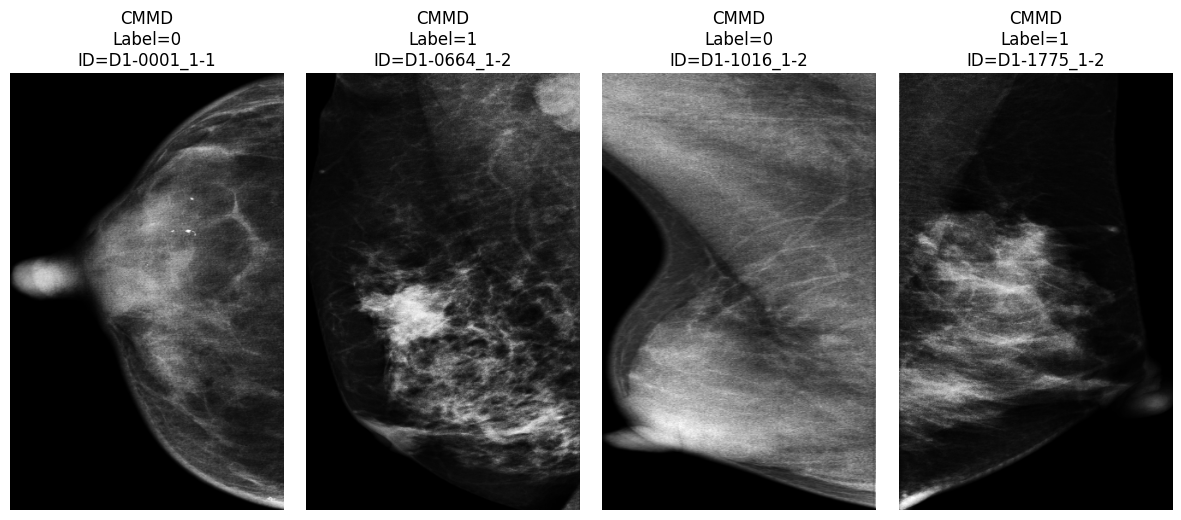

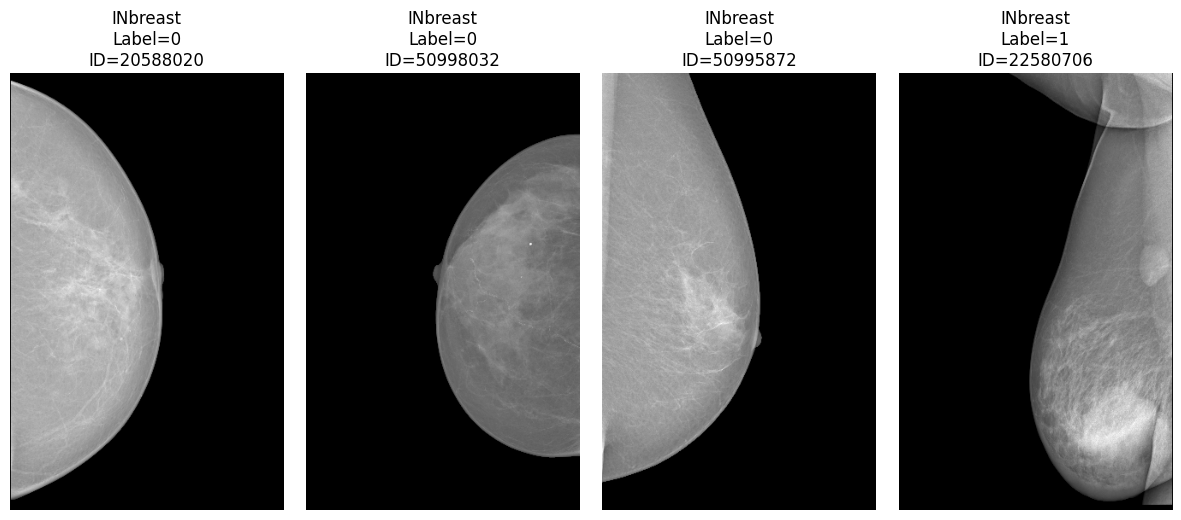

In [25]:
def load_display_image(
    dataset,
    index,
):
    row = (
        dataset.dataframe
        .iloc[
            index
        ]
    )

    binary_data = (
        dataset._read_binary(
            row
        )
    )

    if (
        dataset.dataset_name
        == "CMMD"
    ):
        image_rgb = (
            decode_cmmd_png(
                binary_data
            )
        )

    else:
        (
            image_rgb,
            _,
        ) = (
            decode_inbreast_dicom(
                binary_data
            )
        )


    (
        _,
        display_image,
    ) = (
        student_preprocess_rgb(
            image_rgb
        )
    )

    return (
        display_image,
        row,
    )


audit_indices = {
    "CMMD": np.linspace(
        0,
        len(
            cmmd_inference_dataset
        ) - 1,
        4,
        dtype=int,
    ),
    "INbreast": np.linspace(
        0,
        len(
            inbreast_inference_dataset
        ) - 1,
        4,
        dtype=int,
    ),
}


for (
    dataset_name,
    indices,
) in audit_indices.items():

    dataset = (
        cmmd_inference_dataset
        if dataset_name
        == "CMMD"
        else
        inbreast_inference_dataset
    )

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(
            12,
            5,
        ),
    )

    for (
        axis,
        index,
    ) in zip(
        axes,
        indices,
    ):
        (
            image,
            row,
        ) = load_display_image(
            dataset,
            int(
                index
            ),
        )

        axis.imshow(
            image,
            cmap="gray",
        )

        axis.set_title(
            f"{dataset_name}\n"
            f"Label={int(row['label'])}\n"
            f"ID={row['image_id']}"
        )

        axis.axis(
            "off"
        )

    plt.tight_layout()
    plt.show()

## **RECONSTRUCT FROZEN MODELS**

### **Baseline Architecture**

In [26]:
def build_baseline_model():
    model = (
        mobilenet_v3_small(
            weights=None
        )
    )

    feature_dim = int(
        model.classifier[
            0
        ].in_features
    )

    model.classifier = (
        nn.Linear(
            feature_dim,
            1,
        )
    )

    return model

### **Exact MoE Components**

In [27]:
class BinaryExpert(
    nn.Module
):
    def __init__(
        self,
        input_dim=576,
        hidden_dim=128,
        dropout=0.2,
    ):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(
                input_dim,
                hidden_dim,
            ),
            nn.Hardswish(),
            nn.Dropout(
                dropout
            ),
            nn.Linear(
                hidden_dim,
                1,
            ),
        )


    def forward(
        self,
        features,
    ):
        return self.network(
            features
        )

In [28]:
class SparseTop2MoEHead(
    nn.Module
):
    def __init__(
        self,
        input_dim=576,
        num_experts=3,
        top_k=2,
        expert_hidden_dim=128,
        router_hidden_dim=128,
        expert_dropout=0.2,
        router_dropout=0.1,
        eps=1e-8,
    ):
        super().__init__()

        self.input_dim = (
            input_dim
        )

        self.num_experts = (
            num_experts
        )

        self.top_k = (
            top_k
        )

        self.eps = eps


        self.router = nn.Sequential(
            nn.Linear(
                input_dim,
                router_hidden_dim,
            ),
            nn.Hardswish(),
            nn.Dropout(
                router_dropout
            ),
            nn.Linear(
                router_hidden_dim,
                num_experts,
            ),
        )


        self.experts = nn.ModuleList([
            BinaryExpert(
                input_dim=(
                    input_dim
                ),
                hidden_dim=(
                    expert_hidden_dim
                ),
                dropout=(
                    expert_dropout
                ),
            )
            for _ in range(
                num_experts
            )
        ])


    def forward(
        self,
        features,
    ):
        router_logits = (
            self.router(
                features
            )
        )


        router_probabilities = (
            torch.softmax(
                router_logits,
                dim=1,
            )
        )


        (
            topk_probabilities,
            topk_indices,
        ) = torch.topk(
            router_probabilities,
            k=self.top_k,
            dim=1,
        )


        topk_probabilities = (
            topk_probabilities
            / topk_probabilities
            .sum(
                dim=1,
                keepdim=True,
            )
            .clamp_min(
                self.eps
            )
        )


        sparse_gates = (
            torch.zeros_like(
                router_probabilities
            )
            .scatter(
                dim=1,
                index=(
                    topk_indices
                ),
                src=(
                    topk_probabilities
                ),
            )
        )


        expert_logits = (
            torch.cat(
                [
                    expert(
                        features
                    )
                    for expert
                    in self.experts
                ],
                dim=1,
            )
        )


        combined_logits = (
            sparse_gates
            * expert_logits
        ).sum(
            dim=1,
            keepdim=True,
        )


        return {
            "logits": (
                combined_logits
            ),
            "expert_logits": (
                expert_logits
            ),
            "router_logits": (
                router_logits
            ),
            "router_probabilities": (
                router_probabilities
            ),
            "sparse_gates": (
                sparse_gates
            ),
            "topk_indices": (
                topk_indices
            ),
        }

### **Exact Deployable Sparse Top-2 Moe**

In [29]:
class MobileNetV3SmallSparseMoE(
    nn.Module
):
    def __init__(
        self,
        num_experts=3,
        top_k=2,
        expert_hidden_dim=128,
        router_hidden_dim=128,
        expert_dropout=0.2,
        router_dropout=0.1,
    ):
        super().__init__()

        backbone = (
            mobilenet_v3_small(
                weights=None
            )
        )


        self.features = (
            backbone.features
        )


        self.avgpool = (
            nn.AdaptiveAvgPool2d(
                1
            )
        )


        self.feature_dim = int(
            backbone.classifier[
                0
            ].in_features
        )


        self.num_experts = (
            num_experts
        )

        self.top_k = (
            top_k
        )


        self.moe_head = (
            SparseTop2MoEHead(
                input_dim=(
                    self.feature_dim
                ),
                num_experts=(
                    num_experts
                ),
                top_k=(
                    top_k
                ),
                expert_hidden_dim=(
                    expert_hidden_dim
                ),
                router_hidden_dim=(
                    router_hidden_dim
                ),
                expert_dropout=(
                    expert_dropout
                ),
                router_dropout=(
                    router_dropout
                ),
            )
        )


    def encode(
        self,
        images,
    ):
        raw_features = (
            self.features(
                images
            )
        )

        pooled_features = (
            self.avgpool(
                raw_features
            )
        )

        pooled_features = (
            torch.flatten(
                pooled_features,
                start_dim=1,
            )
        )

        return (
            pooled_features
        )


    def forward(
        self,
        images,
    ):
        pooled_features = (
            self.encode(
                images
            )
        )

        output = (
            self.moe_head(
                pooled_features
            )
        )

        output[
            "pooled_features"
        ] = (
            pooled_features
        )

        return output

### **Load All Three Frozen Models**

In [30]:
def checkpoint_state_dict(
    checkpoint_path,
):
    checkpoint = (
        load_checkpoint_cpu(
            checkpoint_path
        )
    )

    return (
        checkpoint[
            "model_state_dict"
        ]
    )


# -------------------------------------------------
# Baseline
# -------------------------------------------------

baseline_model = (
    build_baseline_model()
)

baseline_state_dict = (
    checkpoint_state_dict(
        BASELINE_CHECKPOINT_PATH
    )
)

baseline_load_result = (
    baseline_model
    .load_state_dict(
        baseline_state_dict,
        strict=True,
    )
)

baseline_model = (
    baseline_model
    .to(
        DEVICE
    )
    .eval()
)


# -------------------------------------------------
# MoE
# -------------------------------------------------

moe_model = (
    MobileNetV3SmallSparseMoE()
)

moe_state_dict = (
    checkpoint_state_dict(
        MOE_CHECKPOINT_PATH
    )
)

moe_load_result = (
    moe_model
    .load_state_dict(
        moe_state_dict,
        strict=True,
    )
)

moe_model = (
    moe_model
    .to(
        DEVICE
    )
    .eval()
)


# -------------------------------------------------
# MoE + KD
# -------------------------------------------------

kd_model = (
    MobileNetV3SmallSparseMoE()
)

kd_full_state_dict = (
    checkpoint_state_dict(
        KD_CHECKPOINT_PATH
    )
)


kd_deployable_state_dict = {
    key: value
    for (
        key,
        value,
    )
    in (
        kd_full_state_dict
        .items()
    )
    if not key.startswith(
        "distill_projector."
    )
}


kd_load_result = (
    kd_model
    .load_state_dict(
        kd_deployable_state_dict,
        strict=True,
    )
)


kd_model = (
    kd_model
    .to(
        DEVICE
    )
    .eval()
)


print(
    "All checkpoint state_dicts "
    "loaded strictly."
)

All checkpoint state_dicts loaded strictly.


### **Verify Parameter Counts Against Notebook 06**

In [31]:
def count_parameters(
    model,
):
    return sum(
        parameter.numel()
        for parameter
        in model.parameters()
    )


parameter_summary = pd.DataFrame([
    {
        "model": (
            "Baseline"
        ),
        "parameters": (
            count_parameters(
                baseline_model
            )
        ),
        "expected": (
            927585
        ),
    },
    {
        "model": (
            "MoE"
        ),
        "parameters": (
            count_parameters(
                moe_model
            )
        ),
        "expected": (
            1223206
        ),
    },
    {
        "model": (
            "MoE+KD deployable"
        ),
        "parameters": (
            count_parameters(
                kd_model
            )
        ),
        "expected": (
            1223206
        ),
    },
])


parameter_summary[
    "matches_expected"
] = (
    parameter_summary[
        "parameters"
    ]
    == parameter_summary[
        "expected"
    ]
)


display(
    parameter_summary
)


assert (
    parameter_summary[
        "matches_expected"
    ].all()
)


print(
    "Parameter-count validation passed."
)

,model,parameters,expected,matches_expected
0,Baseline,927585,927585,True
1,MoE,1223206,1223206,True
2,MoE+KD deployable,1223206,1223206,True


Parameter-count validation passed.


## **DATALOADER AND SANITY INFERENCE**

### **Build Inference Loaders**

In [32]:
EXTERNAL_BATCH_SIZE = 16


cmmd_inference_loader = (
    DataLoader(
        cmmd_inference_dataset,
        batch_size=(
            EXTERNAL_BATCH_SIZE
        ),
        shuffle=False,
        num_workers=0,
        pin_memory=(
            DEVICE.type
            == "cuda"
        ),
    )
)


inbreast_inference_loader = (
    DataLoader(
        inbreast_inference_dataset,
        batch_size=(
            EXTERNAL_BATCH_SIZE
        ),
        shuffle=False,
        num_workers=0,
        pin_memory=(
            DEVICE.type
            == "cuda"
        ),
    )
)


print(
    "CMMD batches:",
    len(
        cmmd_inference_loader
    ),
)

print(
    "INbreast batches:",
    len(
        inbreast_inference_loader
    ),
)

CMMD batches: 128
INbreast batches: 24


### **Get One Batch From Each External Dataset**

In [33]:
cmmd_batch = next(
    iter(
        cmmd_inference_loader
    )
)

inbreast_batch = next(
    iter(
        inbreast_inference_loader
    )
)


print(
    "CMMD batch image shape:",
    cmmd_batch[
        "images"
    ].shape,
)

print(
    "CMMD labels:",
    cmmd_batch[
        "labels"
    ].shape,
)


print(
    "\nINbreast batch image shape:",
    inbreast_batch[
        "images"
    ].shape,
)

print(
    "INbreast labels:",
    inbreast_batch[
        "labels"
    ].shape,
)


assert (
    cmmd_batch[
        "images"
    ].shape[1:]
    == (
        3,
        512,
        320,
    )
)

assert (
    inbreast_batch[
        "images"
    ].shape[1:]
    == (
        3,
        512,
        320,
    )
)

CMMD batch image shape: torch.Size([16, 3, 512, 320])
CMMD labels: torch.Size([16])

INbreast batch image shape: torch.Size([16, 3, 512, 320])
INbreast labels: torch.Size([16])


### **Sanity Inference Utility**

In [34]:
@torch.inference_mode()
def sanity_inference(
    model,
    batch,
    model_type,
):
    images = (
        batch[
            "images"
        ]
        .to(
            DEVICE,
            non_blocking=True,
        )
    )


    with torch.autocast(
        device_type=(
            DEVICE.type
        ),
        enabled=(
            USE_AMP
        ),
    ):

        if (
            model_type
            == "baseline"
        ):
            logits = (
                model(
                    images
                )
            )

            output = {
                "logits": (
                    logits
                )
            }

        else:
            output = (
                model(
                    images
                )
            )

            logits = (
                output[
                    "logits"
                ]
            )


    probabilities = (
        torch.sigmoid(
            logits.float()
        )
        .squeeze(1)
    )


    result = {
        "logits_shape": (
            tuple(
                logits.shape
            )
        ),
        "probability_min": (
            float(
                probabilities.min()
            )
        ),
        "probability_max": (
            float(
                probabilities.max()
            )
        ),
        "probability_mean": (
            float(
                probabilities.mean()
            )
        ),
        "all_finite": (
            bool(
                torch.isfinite(
                    probabilities
                )
                .all()
            )
        ),
    }


    if (
        model_type
        != "baseline"
    ):
        result[
            "router_shape"
        ] = tuple(
            output[
                "router_probabilities"
            ].shape
        )

        result[
            "router_mean"
        ] = (
            output[
                "router_probabilities"
            ]
            .float()
            .mean(
                dim=0
            )
            .cpu()
            .numpy()
            .round(
                4
            )
            .tolist()
        )

        result[
            "topk_shape"
        ] = tuple(
            output[
                "topk_indices"
            ].shape
        )


    return result

### **Sanity Inference on CMMD**

In [35]:
cmmd_sanity_results = {}


cmmd_sanity_results[
    "Baseline"
] = sanity_inference(
    baseline_model,
    cmmd_batch,
    "baseline",
)


cmmd_sanity_results[
    "MoE"
] = sanity_inference(
    moe_model,
    cmmd_batch,
    "moe",
)


cmmd_sanity_results[
    "MoE+KD"
] = sanity_inference(
    kd_model,
    cmmd_batch,
    "moe",
)


for (
    model_name,
    result,
) in (
    cmmd_sanity_results
    .items()
):

    print(
        "\n",
        model_name,
    )

    print(
        json.dumps(
            result,
            indent=4,
        )
    )


 Baseline
{
    "logits_shape": [
        16,
        1
    ],
    "probability_min": 0.12984344363212585,
    "probability_max": 0.9490118622779846,
    "probability_mean": 0.686389684677124,
    "all_finite": true
}

 MoE
{
    "logits_shape": [
        16,
        1
    ],
    "probability_min": 0.07952635735273361,
    "probability_max": 0.9990026354789734,
    "probability_mean": 0.843098521232605,
    "all_finite": true,
    "router_shape": [
        16,
        3
    ],
    "router_mean": [
        0.6672999858856201,
        0.15060000121593475,
        0.18209999799728394
    ],
    "topk_shape": [
        16,
        2
    ]
}

 MoE+KD
{
    "logits_shape": [
        16,
        1
    ],
    "probability_min": 0.8185256123542786,
    "probability_max": 0.9982157945632935,
    "probability_mean": 0.9639639258384705,
    "all_finite": true,
    "router_shape": [
        16,
        3
    ],
    "router_mean": [
        0.28630000352859497,
        0.6025000214576721,
        0

### **Sanity Inference on INbreast**

In [36]:
inbreast_sanity_results = {}


inbreast_sanity_results[
    "Baseline"
] = sanity_inference(
    baseline_model,
    inbreast_batch,
    "baseline",
)


inbreast_sanity_results[
    "MoE"
] = sanity_inference(
    moe_model,
    inbreast_batch,
    "moe",
)


inbreast_sanity_results[
    "MoE+KD"
] = sanity_inference(
    kd_model,
    inbreast_batch,
    "moe",
)


for (
    model_name,
    result,
) in (
    inbreast_sanity_results
    .items()
):

    print(
        "\n",
        model_name,
    )

    print(
        json.dumps(
            result,
            indent=4,
        )
    )


 Baseline
{
    "logits_shape": [
        16,
        1
    ],
    "probability_min": 0.07436569780111313,
    "probability_max": 0.7834919095039368,
    "probability_mean": 0.4888342022895813,
    "all_finite": true
}

 MoE
{
    "logits_shape": [
        16,
        1
    ],
    "probability_min": 0.1243429034948349,
    "probability_max": 0.9141308665275574,
    "probability_mean": 0.5361906886100769,
    "all_finite": true,
    "router_shape": [
        16,
        3
    ],
    "router_mean": [
        0.40220001339912415,
        0.2662999927997589,
        0.33160001039505005
    ],
    "topk_shape": [
        16,
        2
    ]
}

 MoE+KD
{
    "logits_shape": [
        16,
        1
    ],
    "probability_min": 0.0625704973936081,
    "probability_max": 0.9726448059082031,
    "probability_mean": 0.576076328754425,
    "all_finite": true,
    "router_shape": [
        16,
        3
    ],
    "router_mean": [
        0.3041999936103821,
        0.3978999853134155,
        0.

### **Final Sanity Assertions**

In [37]:
for result_dictionary in [
    cmmd_sanity_results,
    inbreast_sanity_results,
]:
    for (
        model_name,
        result,
    ) in (
        result_dictionary
        .items()
    ):

        assert (
            result[
                "logits_shape"
            ][1]
            == 1
        )

        assert (
            result[
                "all_finite"
            ]
        )

        assert (
            0.0
            <= result[
                "probability_min"
            ]
            <= 1.0
        )

        assert (
            0.0
            <= result[
                "probability_max"
            ]
            <= 1.0
        )


print(
    "All external sanity inference "
    "assertions passed."
)

All external sanity inference assertions passed.


## **FULL FROZEN EXTERNAL INFERENCE**

### **Prediction Output Paths**

In [38]:
PREDICTION_OUTPUT_DIR = (
    EXTERNAL_OUTPUT_ROOT
    / "predictions"
)

PREDICTION_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


CMMD_FULL_PREDICTION_PATH = (
    PREDICTION_OUTPUT_DIR
    / "cmmd_primary_all_models_predictions.csv"
)

INBREAST_FULL_PREDICTION_PATH = (
    PREDICTION_OUTPUT_DIR
    / "inbreast_broad_all_models_predictions.csv"
)


CMMD_STRICT_PREDICTION_PATH = (
    PREDICTION_OUTPUT_DIR
    / "cmmd_strict_all_models_predictions.csv"
)

INBREAST_STRICT_PREDICTION_PATH = (
    PREDICTION_OUTPUT_DIR
    / "inbreast_strict_all_models_predictions.csv"
)


print(
    "Prediction output directory:",
    PREDICTION_OUTPUT_DIR,
)

Prediction output directory: /content/drive/MyDrive/Research/outputs/external_validation/predictions


### **Full-inference Function**

In [40]:
@torch.inference_mode()
def run_external_inference(
    model,
    dataloader,
    model_name,
    model_type,
):
    model.eval()

    records = []
    start_time = time.perf_counter()

    for batch_index, batch in enumerate(
        dataloader
    ):
        images = (
            batch["images"]
            .to(
                DEVICE,
                non_blocking=True,
            )
        )

        # Mixed precision only when CUDA is available.
        with torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):

            if model_type == "baseline":
                logits = model(
                    images
                )

                model_output = None

            else:
                model_output = model(
                    images
                )

                logits = (
                    model_output[
                        "logits"
                    ]
                )

        # --------------------------------------------------
        # Final model outputs
        # --------------------------------------------------

        logits_cpu = (
            logits
            .float()
            .squeeze(1)
            .cpu()
        )

        probabilities_cpu = (
            torch.sigmoid(
                logits_cpu
            )
        )

        logits_numpy = (
            logits_cpu
            .numpy()
        )

        probabilities_numpy = (
            probabilities_cpu
            .numpy()
        )

        batch_size = len(
            probabilities_numpy
        )

        # --------------------------------------------------
        # MoE-specific outputs
        # --------------------------------------------------

        if model_type != "baseline":

            router_probabilities = (
                model_output[
                    "router_probabilities"
                ]
                .float()
                .cpu()
                .numpy()
            )

            expert_logits = (
                model_output[
                    "expert_logits"
                ]
                .float()
                .cpu()
                .numpy()
            )

            sparse_gates = (
                model_output[
                    "sparse_gates"
                ]
                .float()
                .cpu()
                .numpy()
            )

            topk_indices = (
                model_output[
                    "topk_indices"
                ]
                .cpu()
                .numpy()
            )

        # --------------------------------------------------
        # Build per-image prediction records
        # --------------------------------------------------

        for item_index in range(
            batch_size
        ):
            record = {
                "model": model_name,

                "dataset_name": (
                    batch[
                        "dataset_name"
                    ][
                        item_index
                    ]
                ),

                "patient_id": (
                    batch[
                        "patient_id"
                    ][
                        item_index
                    ]
                ),

                "image_id": (
                    batch[
                        "image_id"
                    ][
                        item_index
                    ]
                ),

                "relative_path": (
                    batch[
                        "relative_path"
                    ][
                        item_index
                    ]
                ),

                "label": int(
                    batch[
                        "labels"
                    ][
                        item_index
                    ].item()
                ),

                "logit": float(
                    logits_numpy[
                        item_index
                    ]
                ),

                "probability": float(
                    probabilities_numpy[
                        item_index
                    ]
                ),
            }

            # ----------------------------------------------
            # Store routing information for MoE models
            # ----------------------------------------------

            if model_type != "baseline":

                for expert_index in range(
                    3
                ):
                    record[
                        f"router_probability_e{expert_index + 1}"
                    ] = float(
                        router_probabilities[
                            item_index,
                            expert_index,
                        ]
                    )

                    record[
                        f"expert_logit_e{expert_index + 1}"
                    ] = float(
                        expert_logits[
                            item_index,
                            expert_index,
                        ]
                    )

                    record[
                        f"sparse_gate_e{expert_index + 1}"
                    ] = float(
                        sparse_gates[
                            item_index,
                            expert_index,
                        ]
                    )

                # PyTorch indices are zero-based.
                # Store human-readable expert numbers 1, 2, 3.
                record[
                    "top1_expert"
                ] = int(
                    topk_indices[
                        item_index,
                        0,
                    ]
                    + 1
                )

                record[
                    "top2_expert"
                ] = int(
                    topk_indices[
                        item_index,
                        1,
                    ]
                    + 1
                )

            records.append(
                record
            )

        # --------------------------------------------------
        # Progress
        # --------------------------------------------------

        if (
            (batch_index + 1) % 25 == 0
            or
            (batch_index + 1) == len(
                dataloader
            )
        ):
            print(
                f"{model_name:10s} | "
                f"{batch_index + 1:4d}/"
                f"{len(dataloader):4d} batches"
            )

    # ------------------------------------------------------
    # Final summary
    # ------------------------------------------------------

    elapsed_seconds = (
        time.perf_counter()
        - start_time
    )

    predictions = pd.DataFrame(
        records
    )

    print(
        f"\n{model_name} completed:"
    )

    print(
        "  Images:",
        len(
            predictions
        ),
    )

    print(
        "  Probability range:",
        (
            predictions[
                "probability"
            ].min(),
            predictions[
                "probability"
            ].max(),
        ),
    )

    print(
        "  Probability mean:",
        predictions[
            "probability"
        ].mean(),
    )

    print(
        "  Elapsed seconds:",
        round(
            elapsed_seconds,
            2,
        ),
    )

    return (
        predictions,
        elapsed_seconds,
    )

### **Run All Models on CMMD Primary**

In [41]:
cmmd_prediction_frames = []

cmmd_inference_times = {}


for (
    model_name,
    model,
    model_type,
) in [
    (
        "Baseline",
        baseline_model,
        "baseline",
    ),
    (
        "MoE",
        moe_model,
        "moe",
    ),
    (
        "MoE+KD",
        kd_model,
        "moe",
    ),
]:

    print(
        "\n"
        + "=" * 80
    )

    print(
        "CMMD |",
        model_name,
    )

    print(
        "=" * 80
    )


    (
        prediction_df,
        elapsed_seconds,
    ) = run_external_inference(
        model=model,
        dataloader=(
            cmmd_inference_loader
        ),
        model_name=(
            model_name
        ),
        model_type=(
            model_type
        ),
    )


    cmmd_prediction_frames.append(
        prediction_df
    )

    cmmd_inference_times[
        model_name
    ] = (
        elapsed_seconds
    )


cmmd_all_predictions = (
    pd.concat(
        cmmd_prediction_frames,
        ignore_index=True,
    )
)


print(
    "\nCMMD prediction rows:",
    len(
        cmmd_all_predictions
    ),
)


CMMD | Baseline
Baseline   |   25/ 128 batches
Baseline   |   50/ 128 batches
Baseline   |   75/ 128 batches
Baseline   |  100/ 128 batches
Baseline   |  125/ 128 batches
Baseline   |  128/ 128 batches

Baseline completed:
  Images: 2046
  Probability range: (0.01829933375120163, 0.995685338973999)
  Probability mean: 0.7477739494683573
  Elapsed seconds: 42.01

CMMD | MoE
MoE        |   25/ 128 batches
MoE        |   50/ 128 batches
MoE        |   75/ 128 batches
MoE        |  100/ 128 batches
MoE        |  125/ 128 batches
MoE        |  128/ 128 batches

MoE completed:
  Images: 2046
  Probability range: (0.00550693366676569, 0.9999676942825317)
  Probability mean: 0.92570446542385
  Elapsed seconds: 31.78

CMMD | MoE+KD
MoE+KD     |   25/ 128 batches
MoE+KD     |   50/ 128 batches
MoE+KD     |   75/ 128 batches
MoE+KD     |  100/ 128 batches
MoE+KD     |  125/ 128 batches
MoE+KD     |  128/ 128 batches

MoE+KD completed:
  Images: 2046
  Probability range: (0.037536732852458954, 0.

### **Run All Models on INbreast Broad**

In [42]:
inbreast_prediction_frames = []

inbreast_inference_times = {}


for (
    model_name,
    model,
    model_type,
) in [
    (
        "Baseline",
        baseline_model,
        "baseline",
    ),
    (
        "MoE",
        moe_model,
        "moe",
    ),
    (
        "MoE+KD",
        kd_model,
        "moe",
    ),
]:

    print(
        "\n"
        + "=" * 80
    )

    print(
        "INbreast |",
        model_name,
    )

    print(
        "=" * 80
    )


    (
        prediction_df,
        elapsed_seconds,
    ) = run_external_inference(
        model=model,
        dataloader=(
            inbreast_inference_loader
        ),
        model_name=(
            model_name
        ),
        model_type=(
            model_type
        ),
    )


    inbreast_prediction_frames.append(
        prediction_df
    )

    inbreast_inference_times[
        model_name
    ] = (
        elapsed_seconds
    )


inbreast_all_predictions = (
    pd.concat(
        inbreast_prediction_frames,
        ignore_index=True,
    )
)


print(
    "\nINbreast prediction rows:",
    len(
        inbreast_all_predictions
    ),
)


INbreast | Baseline
Baseline   |   24/  24 batches

Baseline completed:
  Images: 383
  Probability range: (0.04352813959121704, 0.896975576877594)
  Probability mean: 0.5493288644280664
  Elapsed seconds: 112.83

INbreast | MoE
MoE        |   24/  24 batches

MoE completed:
  Images: 383
  Probability range: (0.05523360148072243, 0.993410050868988)
  Probability mean: 0.6036134275264902
  Elapsed seconds: 88.66

INbreast | MoE+KD
MoE+KD     |   24/  24 batches

MoE+KD completed:
  Images: 383
  Probability range: (0.0625704973936081, 0.9919325709342957)
  Probability mean: 0.721011219852587
  Elapsed seconds: 88.24

INbreast prediction rows: 1149


### **Validate Prediction Integrity**

In [43]:
EXPECTED_MODELS = {
    "Baseline",
    "MoE",
    "MoE+KD",
}


def validate_prediction_table(
    prediction_df,
    expected_images,
    dataset_name,
):
    assert set(
        prediction_df[
            "model"
        ].unique()
    ) == EXPECTED_MODELS


    for model_name in (
        EXPECTED_MODELS
    ):
        model_df = (
            prediction_df[
                prediction_df[
                    "model"
                ]
                == model_name
            ]
        )

        assert (
            len(
                model_df
            )
            == expected_images
        )

        assert (
            model_df[
                "relative_path"
            ].nunique()
            == expected_images
        )

        assert (
            model_df[
                "probability"
            ].between(
                0.0,
                1.0,
            ).all()
        )

        assert np.isfinite(
            model_df[
                "probability"
            ].to_numpy()
        ).all()

        assert np.isfinite(
            model_df[
                "logit"
            ].to_numpy()
        ).all()


    print(
        dataset_name,
        "prediction integrity passed."
    )


validate_prediction_table(
    cmmd_all_predictions,
    expected_images=2046,
    dataset_name="CMMD",
)

validate_prediction_table(
    inbreast_all_predictions,
    expected_images=383,
    dataset_name="INbreast",
)

CMMD prediction integrity passed.
INbreast prediction integrity passed.


### **Cross-model Alignment Check**

In [44]:
def validate_model_alignment(
    prediction_df,
    dataset_name,
):
    reference = (
        prediction_df[
            prediction_df[
                "model"
            ]
            == "Baseline"
        ][
            [
                "relative_path",
                "patient_id",
                "image_id",
                "label",
            ]
        ]
        .sort_values(
            "relative_path"
        )
        .reset_index(
            drop=True
        )
    )


    for model_name in [
        "MoE",
        "MoE+KD",
    ]:
        comparison = (
            prediction_df[
                prediction_df[
                    "model"
                ]
                == model_name
            ][
                [
                    "relative_path",
                    "patient_id",
                    "image_id",
                    "label",
                ]
            ]
            .sort_values(
                "relative_path"
            )
            .reset_index(
                drop=True
            )
        )

        assert (
            reference.equals(
                comparison
            )
        )


    print(
        dataset_name,
        "cross-model alignment passed."
    )


validate_model_alignment(
    cmmd_all_predictions,
    "CMMD",
)

validate_model_alignment(
    inbreast_all_predictions,
    "INbreast",
)

CMMD cross-model alignment passed.
INbreast cross-model alignment passed.


### **Save Parent-cohort Prediction Files**

In [45]:
cmmd_all_predictions.to_csv(
    CMMD_FULL_PREDICTION_PATH,
    index=False,
)


inbreast_all_predictions.to_csv(
    INBREAST_FULL_PREDICTION_PATH,
    index=False,
)


print(
    "Saved:",
    CMMD_FULL_PREDICTION_PATH,
)

print(
    "Saved:",
    INBREAST_FULL_PREDICTION_PATH,
)

Saved: /content/drive/MyDrive/Research/outputs/external_validation/predictions/cmmd_primary_all_models_predictions.csv
Saved: /content/drive/MyDrive/Research/outputs/external_validation/predictions/inbreast_broad_all_models_predictions.csv


### **Derive CMMD Strict Prediction Subset**

In [46]:
cmmd_strict_relative_paths = set(
    cmmd_strict_df[
        "relative_path"
    ].astype(str)
)


cmmd_strict_predictions = (
    cmmd_all_predictions[
        cmmd_all_predictions[
            "relative_path"
        ].isin(
            cmmd_strict_relative_paths
        )
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


assert (
    len(
        cmmd_strict_predictions
    )
    == (
        len(
            cmmd_strict_df
        )
        * 3
    )
)


cmmd_strict_predictions.to_csv(
    CMMD_STRICT_PREDICTION_PATH,
    index=False,
)


print(
    "CMMD strict prediction rows:",
    len(
        cmmd_strict_predictions
    ),
)

print(
    "Saved:",
    CMMD_STRICT_PREDICTION_PATH,
)

CMMD strict prediction rows: 5658
Saved: /content/drive/MyDrive/Research/outputs/external_validation/predictions/cmmd_strict_all_models_predictions.csv


### **Derive INbreast Strict Prediction Subset**

In [47]:
inbreast_strict_relative_paths = set(
    inbreast_strict_df[
        "relative_path"
    ].astype(str)
)


inbreast_strict_predictions = (
    inbreast_all_predictions[
        inbreast_all_predictions[
            "relative_path"
        ].isin(
            inbreast_strict_relative_paths
        )
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


assert (
    len(
        inbreast_strict_predictions
    )
    == (
        len(
            inbreast_strict_df
        )
        * 3
    )
)


inbreast_strict_predictions.to_csv(
    INBREAST_STRICT_PREDICTION_PATH,
    index=False,
)


print(
    "INbreast strict prediction rows:",
    len(
        inbreast_strict_predictions
    ),
)

print(
    "Saved:",
    INBREAST_STRICT_PREDICTION_PATH,
)

INbreast strict prediction rows: 1023
Saved: /content/drive/MyDrive/Research/outputs/external_validation/predictions/inbreast_strict_all_models_predictions.csv


### **Probability Distribution Summary**

In [48]:
prediction_distribution_summary = (
    pd.concat(
        [
            (
                cmmd_all_predictions
                .assign(
                    cohort=(
                        "CMMD primary"
                    )
                )
            ),
            (
                inbreast_strict_predictions
                .assign(
                    cohort=(
                        "INbreast strict"
                    )
                )
            ),
        ],
        ignore_index=True,
    )
    .groupby(
        [
            "cohort",
            "model",
            "label",
        ]
    )[
        "probability"
    ]
    .agg(
        [
            "count",
            "mean",
            "std",
            "median",
            "min",
            "max",
        ]
    )
    .reset_index()
)


display(
    prediction_distribution_summary
)

,cohort,model,label,count,mean,std,median,min,max
0,CMMD primary,Baseline,0,944,0.724444,0.236863,0.808143,0.027481,0.993123
1,CMMD primary,Baseline,1,1102,0.767759,0.215392,0.845560,0.018299,0.995685
2,CMMD primary,MoE,0,944,0.913124,0.171884,0.981119,0.049204,0.999934
3,CMMD primary,MoE,1,1102,0.936482,0.134792,0.986249,0.005507,0.999968
4,CMMD primary,MoE+KD,0,944,0.967514,0.099626,0.991286,0.046825,0.999697
5,CMMD primary,MoE+KD,1,1102,0.968966,0.094287,0.992498,0.037537,0.999795
6,INbreast strict,Baseline,0,285,0.545281,0.201710,0.583678,0.043528,0.896976
7,INbreast strict,Baseline,1,56,0.588371,0.190925,0.612266,0.096877,0.860017
8,INbreast strict,MoE,0,285,0.597800,0.252200,0.617806,0.055234,0.972391
9,INbreast strict,MoE,1,56,0.617243,0.256387,0.697595,0.094565,0.960027


## **EXTERNAL POINT-ESTIMATE METRICS**

### **Metric Function**

In [49]:
def compute_binary_metrics(
    y_true,
    y_probability,
    threshold,
):
    y_true = np.asarray(
        y_true,
        dtype=int,
    )

    y_probability = np.asarray(
        y_probability,
        dtype=float,
    )

    y_pred = (
        y_probability
        >= threshold
    ).astype(
        int
    )


    tn, fp, fn, tp = (
        confusion_matrix(
            y_true,
            y_pred,
            labels=[
                0,
                1,
            ],
        )
        .ravel()
    )


    sensitivity = (
        tp
        / (
            tp
            + fn
        )
        if (
            tp
            + fn
        )
        > 0
        else np.nan
    )


    specificity = (
        tn
        / (
            tn
            + fp
        )
        if (
            tn
            + fp
        )
        > 0
        else np.nan
    )


    return {
        "roc_auc": (
            roc_auc_score(
                y_true,
                y_probability,
            )
        ),
        "average_precision": (
            average_precision_score(
                y_true,
                y_probability,
            )
        ),
        "threshold": (
            threshold
        ),
        "sensitivity": (
            sensitivity
        ),
        "specificity": (
            specificity
        ),
        "balanced_accuracy": (
            balanced_accuracy_score(
                y_true,
                y_pred,
            )
        ),
        "f1": (
            f1_score(
                y_true,
                y_pred,
                zero_division=0,
            )
        ),
        "precision": (
            precision_score(
                y_true,
                y_pred,
                zero_division=0,
            )
        ),
        "tn": int(
            tn
        ),
        "fp": int(
            fp
        ),
        "fn": int(
            fn
        ),
        "tp": int(
            tp
        ),
        "predicted_positive_rate": float(
            y_pred.mean()
        ),
        "mean_probability": float(
            y_probability.mean()
        ),
    }

### **Cohort Evaluation Function**

In [50]:
def evaluate_external_cohort(
    prediction_df,
    cohort_name,
    analysis_role,
):
    records = []


    for model_name in [
        "Baseline",
        "MoE",
        "MoE+KD",
    ]:
        model_df = (
            prediction_df[
                prediction_df[
                    "model"
                ]
                == model_name
            ]
            .copy()
        )


        metrics = (
            compute_binary_metrics(
                y_true=(
                    model_df[
                        "label"
                    ]
                    .to_numpy()
                ),
                y_probability=(
                    model_df[
                        "probability"
                    ]
                    .to_numpy()
                ),
                threshold=(
                    FROZEN_THRESHOLDS[
                        model_name
                    ]
                ),
            )
        )


        records.append({
            "cohort": (
                cohort_name
            ),
            "analysis_role": (
                analysis_role
            ),
            "model": (
                model_name
            ),
            "images": int(
                len(
                    model_df
                )
            ),
            "patients": int(
                model_df[
                    "patient_id"
                ].nunique()
            ),
            **metrics,
        })


    return pd.DataFrame(
        records
    )

### **Compute All Four External Cohorts**

In [51]:
cmmd_primary_metrics = (
    evaluate_external_cohort(
        prediction_df=(
            cmmd_all_predictions
        ),
        cohort_name=(
            "CMMD Expanded Primary"
        ),
        analysis_role=(
            "Primary"
        ),
    )
)


cmmd_strict_metrics = (
    evaluate_external_cohort(
        prediction_df=(
            cmmd_strict_predictions
        ),
        cohort_name=(
            "CMMD Strict Two-Image"
        ),
        analysis_role=(
            "Sensitivity"
        ),
    )
)


inbreast_strict_metrics = (
    evaluate_external_cohort(
        prediction_df=(
            inbreast_strict_predictions
        ),
        cohort_name=(
            "INbreast Strict"
        ),
        analysis_role=(
            "Primary"
        ),
    )
)


inbreast_broad_metrics = (
    evaluate_external_cohort(
        prediction_df=(
            inbreast_all_predictions
        ),
        cohort_name=(
            "INbreast Broad"
        ),
        analysis_role=(
            "Sensitivity"
        ),
    )
)


external_point_metrics = (
    pd.concat(
        [
            cmmd_primary_metrics,
            cmmd_strict_metrics,
            inbreast_strict_metrics,
            inbreast_broad_metrics,
        ],
        ignore_index=True,
    )
)

### **Display External Point Estimates**

In [52]:
metric_display_columns = [
    "cohort",
    "analysis_role",
    "model",
    "images",
    "patients",
    "roc_auc",
    "average_precision",
    "threshold",
    "sensitivity",
    "specificity",
    "balanced_accuracy",
    "f1",
    "precision",
    "predicted_positive_rate",
    "tn",
    "fp",
    "fn",
    "tp",
]


external_point_metrics_display = (
    external_point_metrics[
        metric_display_columns
    ]
    .copy()
)


for column in [
    "roc_auc",
    "average_precision",
    "threshold",
    "sensitivity",
    "specificity",
    "balanced_accuracy",
    "f1",
    "precision",
    "predicted_positive_rate",
]:
    external_point_metrics_display[
        column
    ] = (
        external_point_metrics_display[
            column
        ]
        .round(
            4
        )
    )


display(
    external_point_metrics_display
)

,cohort,analysis_role,model,images,patients,roc_auc,average_precision,threshold,sensitivity,specificity,balanced_accuracy,f1,precision,predicted_positive_rate,tn,fp,fn,tp
0,CMMD Expanded Primary,Primary,Baseline,2046,1023,0.5531,0.5739,0.5166,0.8603,0.2087,0.5345,0.6779,0.5593,0.8284,197,747,154,948
1,CMMD Expanded Primary,Primary,MoE,2046,1023,0.5359,0.5622,0.3496,0.9855,0.0307,0.5081,0.7000,0.5427,0.9780,29,915,16,1086
2,CMMD Expanded Primary,Primary,MoE+KD,2046,1023,0.5199,0.5407,0.2530,0.9946,0.0095,0.5020,0.6996,0.5396,0.9927,9,935,6,1096
3,CMMD Strict Two-Image,Sensitivity,Baseline,1886,943,0.5595,0.6091,0.5166,0.8583,0.2283,0.5433,0.7052,0.5985,0.8213,184,622,153,927
4,CMMD Strict Two-Image,Sensitivity,MoE,1886,943,0.5352,0.5976,0.3496,0.9852,0.0298,0.5075,0.7273,0.5764,0.9788,24,782,16,1064
5,CMMD Strict Two-Image,Sensitivity,MoE+KD,1886,943,0.5233,0.5796,0.2530,0.9944,0.0087,0.5016,0.7274,0.5734,0.9931,7,799,6,1074
6,INbreast Strict,Primary,Baseline,341,100,0.5628,0.1998,0.5166,0.6964,0.3965,0.5465,0.2921,0.1848,0.6188,113,172,17,39
7,INbreast Strict,Primary,MoE,341,100,0.5206,0.1766,0.3496,0.7500,0.2035,0.4768,0.2585,0.1561,0.7889,58,227,14,42
8,INbreast Strict,Primary,MoE+KD,341,100,0.5521,0.2079,0.2530,0.9107,0.1018,0.5062,0.2810,0.1661,0.9003,29,256,5,51
9,INbreast Broad,Sensitivity,Baseline,383,103,0.5241,0.2818,0.5166,0.6122,0.3965,0.5044,0.3636,0.2586,0.6057,113,172,38,60


### **Save Point-estimate Table**

In [53]:
EXTERNAL_POINT_METRICS_PATH = (
    EXTERNAL_OUTPUT_ROOT
    / "external_point_estimate_metrics.csv"
)


external_point_metrics.to_csv(
    EXTERNAL_POINT_METRICS_PATH,
    index=False,
)


print(
    "Saved:",
    EXTERNAL_POINT_METRICS_PATH,
)

Saved: /content/drive/MyDrive/Research/outputs/external_validation/external_point_estimate_metrics.csv


### **Primary-cohort Compact Table**

In [54]:
primary_external_metrics = (
    external_point_metrics[
        external_point_metrics[
            "analysis_role"
        ]
        == "Primary"
    ][
        [
            "cohort",
            "model",
            "roc_auc",
            "average_precision",
            "sensitivity",
            "specificity",
            "balanced_accuracy",
            "f1",
            "predicted_positive_rate",
        ]
    ]
    .copy()
)


display(
    primary_external_metrics
    .round(
        4
    )
)

,cohort,model,roc_auc,average_precision,sensitivity,specificity,balanced_accuracy,f1,predicted_positive_rate
0,CMMD Expanded Primary,Baseline,0.5531,0.5739,0.8603,0.2087,0.5345,0.6779,0.8284
1,CMMD Expanded Primary,MoE,0.5359,0.5622,0.9855,0.0307,0.5081,0.7000,0.9780
2,CMMD Expanded Primary,MoE+KD,0.5199,0.5407,0.9946,0.0095,0.5020,0.6996,0.9927
6,INbreast Strict,Baseline,0.5628,0.1998,0.6964,0.3965,0.5465,0.2921,0.6188
7,INbreast Strict,MoE,0.5206,0.1766,0.7500,0.2035,0.4768,0.2585,0.7889
8,INbreast Strict,MoE+KD,0.5521,0.2079,0.9107,0.1018,0.5062,0.2810,0.9003


## **PATIENT-CLUSTER BOOTSTRAP 95% CONFIDENCE INTERVALS**

### **Bootstrap Configuration and Helper**

In [55]:
BOOTSTRAP_METRICS = [
    "roc_auc",
    "average_precision",
    "sensitivity",
    "specificity",
    "balanced_accuracy",
    "f1",
]


def build_cluster_bootstrap_sample(
    model_dataframe,
    sampled_patient_ids,
):
    grouped = {
        str(patient_id): group
        for patient_id, group
        in model_dataframe.groupby(
            "patient_id",
            sort=False,
        )
    }

    sampled_parts = []

    for bootstrap_cluster_index, patient_id in enumerate(
        sampled_patient_ids
    ):
        patient_part = (
            grouped[
                str(patient_id)
            ]
            .copy()
        )

        # Creates a unique resampled cluster ID,
        # while preserving all images from that patient.
        patient_part[
            "_bootstrap_cluster_id"
        ] = bootstrap_cluster_index

        sampled_parts.append(
            patient_part
        )

    return pd.concat(
        sampled_parts,
        ignore_index=True,
    )

### **Safe Bootstrap Metric Computation**

In [56]:
def safe_compute_binary_metrics(
    dataframe,
    threshold,
):
    y_true = (
        dataframe[
            "label"
        ]
        .to_numpy(
            dtype=int
        )
    )

    y_probability = (
        dataframe[
            "probability"
        ]
        .to_numpy(
            dtype=float
        )
    )

    if (
        np.unique(
            y_true
        ).size
        < 2
    ):
        return None

    try:
        return compute_binary_metrics(
            y_true=y_true,
            y_probability=y_probability,
            threshold=threshold,
        )

    except Exception:
        return None

### **Patient-cluster Bootstrap for One Cohort**

In [57]:
def patient_cluster_bootstrap(
    prediction_df,
    cohort_name,
    n_bootstrap=2000,
    seed=42,
):
    rng = np.random.default_rng(
        seed
    )

    models = [
        "Baseline",
        "MoE",
        "MoE+KD",
    ]


    reference_df = (
        prediction_df[
            prediction_df[
                "model"
            ]
            == "Baseline"
        ]
    )


    patient_ids = (
        reference_df[
            "patient_id"
        ]
        .astype(str)
        .unique()
    )


    n_patients = len(
        patient_ids
    )


    model_dataframes = {
        model_name: (
            prediction_df[
                prediction_df[
                    "model"
                ]
                == model_name
            ]
            .copy()
        )
        for model_name
        in models
    }


    bootstrap_records = []


    for bootstrap_index in range(
        n_bootstrap
    ):
        sampled_patient_ids = (
            rng.choice(
                patient_ids,
                size=n_patients,
                replace=True,
            )
        )


        replicate_metrics = {}


        replicate_valid = True


        for model_name in models:
            sampled_df = (
                build_cluster_bootstrap_sample(
                    model_dataframes[
                        model_name
                    ],
                    sampled_patient_ids,
                )
            )


            metrics = (
                safe_compute_binary_metrics(
                    sampled_df,
                    threshold=(
                        FROZEN_THRESHOLDS[
                            model_name
                        ]
                    ),
                )
            )


            if metrics is None:
                replicate_valid = False
                break


            replicate_metrics[
                model_name
            ] = metrics


        if not replicate_valid:
            continue


        for model_name in models:
            record = {
                "cohort": (
                    cohort_name
                ),
                "bootstrap_index": (
                    bootstrap_index
                ),
                "model": (
                    model_name
                ),
            }

            for metric_name in (
                BOOTSTRAP_METRICS
            ):
                record[
                    metric_name
                ] = (
                    replicate_metrics[
                        model_name
                    ][
                        metric_name
                    ]
                )

            bootstrap_records.append(
                record
            )


        if (
            (bootstrap_index + 1)
            % 250
            == 0
        ):
            print(
                f"{cohort_name}: "
                f"{bootstrap_index + 1}/"
                f"{n_bootstrap}"
            )


    bootstrap_df = pd.DataFrame(
        bootstrap_records
    )


    valid_replicates = (
        bootstrap_df[
            "bootstrap_index"
        ].nunique()
        if len(
            bootstrap_df
        )
        > 0
        else 0
    )


    print(
        f"\n{cohort_name}"
    )

    print(
        "Patients:",
        n_patients,
    )

    print(
        "Requested replicates:",
        n_bootstrap,
    )

    print(
        "Valid replicates:",
        valid_replicates,
    )


    return bootstrap_df

### **Run Bootstrap on Primary Cohorts**

In [58]:
cmmd_primary_bootstrap = (
    patient_cluster_bootstrap(
        prediction_df=(
            cmmd_all_predictions
        ),
        cohort_name=(
            "CMMD Expanded Primary"
        ),
        n_bootstrap=(
            BOOTSTRAP_REPLICATES
        ),
        seed=(
            BOOTSTRAP_SEED
        ),
    )
)


inbreast_strict_bootstrap = (
    patient_cluster_bootstrap(
        prediction_df=(
            inbreast_strict_predictions
        ),
        cohort_name=(
            "INbreast Strict"
        ),
        n_bootstrap=(
            BOOTSTRAP_REPLICATES
        ),
        seed=(
            BOOTSTRAP_SEED
            + 1
        ),
    )
)


primary_bootstrap_results = (
    pd.concat(
        [
            cmmd_primary_bootstrap,
            inbreast_strict_bootstrap,
        ],
        ignore_index=True,
    )
)

CMMD Expanded Primary: 250/2000
CMMD Expanded Primary: 500/2000
CMMD Expanded Primary: 750/2000
CMMD Expanded Primary: 1000/2000
CMMD Expanded Primary: 1250/2000
CMMD Expanded Primary: 1500/2000
CMMD Expanded Primary: 1750/2000
CMMD Expanded Primary: 2000/2000

CMMD Expanded Primary
Patients: 1023
Requested replicates: 2000
Valid replicates: 2000
INbreast Strict: 250/2000
INbreast Strict: 500/2000
INbreast Strict: 750/2000
INbreast Strict: 1000/2000
INbreast Strict: 1250/2000
INbreast Strict: 1500/2000
INbreast Strict: 1750/2000
INbreast Strict: 2000/2000

INbreast Strict
Patients: 100
Requested replicates: 2000
Valid replicates: 2000


### **Compute Percentile 95% Confidence Intervals**

In [68]:
def bootstrap_ci_summary(
    bootstrap_df,
):
    records = []


    for (
        cohort_name,
        model_name,
    ), group in (
        bootstrap_df
        .groupby(
            [
                "cohort",
                "model",
            ]
        )
    ):
        record = {
            "cohort": (
                cohort_name
            ),
            "model": (
                model_name
            ),
            "bootstrap_replicates": int(
                group[
                    "bootstrap_index"
                ].nunique()
            ),
        }


        for metric_name in (
            BOOTSTRAP_METRICS
        ):
            values = (
                group[
                    metric_name
                ]
                .dropna()
                .to_numpy(
                    dtype=float
                )
            )


            record[
                f"{metric_name}_bootstrap_mean"
            ] = float(
                np.mean(
                    values
                )
            )


            record[
                f"{metric_name}_ci_lower"
            ] = float(
                np.percentile(
                    values,
                    2.5,
                )
            )


            record[
                f"{metric_name}_ci_upper"
            ] = float(
                np.percentile(
                    values,
                    97.5,
                )
            )


        records.append(
            record
        )


    return pd.DataFrame(
        records
    )


primary_bootstrap_ci = (
    bootstrap_ci_summary(
        primary_bootstrap_results
    )
)


display(
    primary_bootstrap_ci.round(
        4
    )
)

,cohort,model,bootstrap_replicates,roc_auc_bootstrap_mean,roc_auc_ci_lower,roc_auc_ci_upper,average_precision_bootstrap_mean,average_precision_ci_lower,average_precision_ci_upper,sensitivity_bootstrap_mean,...,sensitivity_ci_upper,specificity_bootstrap_mean,specificity_ci_lower,specificity_ci_upper,balanced_accuracy_bootstrap_mean,balanced_accuracy_ci_lower,balanced_accuracy_ci_upper,f1_bootstrap_mean,f1_ci_lower,f1_ci_upper
0,CMMD Expanded Primary,Baseline,2000,0.5532,0.5254,0.5802,0.5748,0.5357,0.6131,0.8602,...,0.8833,0.2086,0.1800,0.2376,0.5344,0.5154,0.5527,0.6773,0.6507,0.7044
1,CMMD Expanded Primary,MoE,2000,0.5362,0.5115,0.5607,0.5627,0.5249,0.6004,0.9856,...,0.9927,0.0306,0.0196,0.0431,0.5081,0.5010,0.5149,0.6995,0.6728,0.7258
2,CMMD Expanded Primary,MoE+KD,2000,0.5203,0.4967,0.5435,0.5417,0.5051,0.5781,0.9945,...,0.9991,0.0095,0.0041,0.0162,0.5020,0.4982,0.5058,0.6991,0.6712,0.7248
3,INbreast Strict,Baseline,2000,0.5626,0.4788,0.6483,0.2092,0.1339,0.2980,0.6965,...,0.8104,0.3962,0.3345,0.4552,0.5463,0.4820,0.6086,0.2899,0.2101,0.3704
4,INbreast Strict,MoE,2000,0.5203,0.4186,0.6254,0.1870,0.1176,0.2771,0.7486,...,0.8750,0.2039,0.1518,0.2556,0.4763,0.3977,0.5448,0.2566,0.1767,0.3384
5,INbreast Strict,MoE+KD,2000,0.5521,0.4458,0.6580,0.2190,0.1315,0.3200,0.9099,...,0.9792,0.1017,0.0667,0.1391,0.5058,0.4638,0.5425,0.2791,0.2023,0.3533


### **Merge Point Estimates With Confidence Intervals**

In [60]:
primary_point_metrics = (
    external_point_metrics[
        external_point_metrics[
            "analysis_role"
        ]
        == "Primary"
    ]
    .copy()
)


primary_metrics_with_ci = (
    primary_point_metrics
    .merge(
        primary_bootstrap_ci,
        on=[
            "cohort",
            "model",
        ],
        how="left",
    )
)


display_columns = [
    "cohort",
    "model",
    "roc_auc",
    "roc_auc_ci_lower",
    "roc_auc_ci_upper",
    "average_precision",
    "average_precision_ci_lower",
    "average_precision_ci_upper",
    "sensitivity",
    "sensitivity_ci_lower",
    "sensitivity_ci_upper",
    "specificity",
    "specificity_ci_lower",
    "specificity_ci_upper",
    "balanced_accuracy",
    "balanced_accuracy_ci_lower",
    "balanced_accuracy_ci_upper",
]


display(
    primary_metrics_with_ci[
        display_columns
    ].round(
        4
    )
)

,cohort,model,roc_auc,roc_auc_ci_lower,roc_auc_ci_upper,average_precision,average_precision_ci_lower,average_precision_ci_upper,sensitivity,sensitivity_ci_lower,sensitivity_ci_upper,specificity,specificity_ci_lower,specificity_ci_upper,balanced_accuracy,balanced_accuracy_ci_lower,balanced_accuracy_ci_upper
0,CMMD Expanded Primary,Baseline,0.5531,0.5254,0.5802,0.5739,0.5357,0.6131,0.8603,0.8363,0.8833,0.2087,0.1800,0.2376,0.5345,0.5154,0.5527
1,CMMD Expanded Primary,MoE,0.5359,0.5115,0.5607,0.5622,0.5249,0.6004,0.9855,0.9775,0.9927,0.0307,0.0196,0.0431,0.5081,0.5010,0.5149
2,CMMD Expanded Primary,MoE+KD,0.5199,0.4967,0.5435,0.5407,0.5051,0.5781,0.9946,0.9889,0.9991,0.0095,0.0041,0.0162,0.5020,0.4982,0.5058
3,INbreast Strict,Baseline,0.5628,0.4788,0.6483,0.1998,0.1339,0.2980,0.6964,0.5800,0.8104,0.3965,0.3345,0.4552,0.5465,0.4820,0.6086
4,INbreast Strict,MoE,0.5206,0.4186,0.6254,0.1766,0.1176,0.2771,0.7500,0.6000,0.8750,0.2035,0.1518,0.2556,0.4768,0.3977,0.5448
5,INbreast Strict,MoE+KD,0.5521,0.4458,0.6580,0.2079,0.1315,0.3200,0.9107,0.8333,0.9792,0.1018,0.0667,0.1391,0.5062,0.4638,0.5425


### **Publication-style CI Strings**

In [61]:
def format_metric_ci(
    point,
    lower,
    upper,
):
    return (
        f"{point:.3f} "
        f"({lower:.3f}–{upper:.3f})"
    )


publication_ci_records = []


for _, row in (
    primary_metrics_with_ci
    .iterrows()
):
    publication_ci_records.append({
        "cohort": (
            row[
                "cohort"
            ]
        ),
        "model": (
            row[
                "model"
            ]
        ),
        "ROC-AUC (95% CI)": (
            format_metric_ci(
                row[
                    "roc_auc"
                ],
                row[
                    "roc_auc_ci_lower"
                ],
                row[
                    "roc_auc_ci_upper"
                ],
            )
        ),
        "AP (95% CI)": (
            format_metric_ci(
                row[
                    "average_precision"
                ],
                row[
                    "average_precision_ci_lower"
                ],
                row[
                    "average_precision_ci_upper"
                ],
            )
        ),
        "Sensitivity (95% CI)": (
            format_metric_ci(
                row[
                    "sensitivity"
                ],
                row[
                    "sensitivity_ci_lower"
                ],
                row[
                    "sensitivity_ci_upper"
                ],
            )
        ),
        "Specificity (95% CI)": (
            format_metric_ci(
                row[
                    "specificity"
                ],
                row[
                    "specificity_ci_lower"
                ],
                row[
                    "specificity_ci_upper"
                ],
            )
        ),
        "Balanced Accuracy (95% CI)": (
            format_metric_ci(
                row[
                    "balanced_accuracy"
                ],
                row[
                    "balanced_accuracy_ci_lower"
                ],
                row[
                    "balanced_accuracy_ci_upper"
                ],
            )
        ),
    })


publication_ci_table = pd.DataFrame(
    publication_ci_records
)


display(
    publication_ci_table
)

,cohort,model,ROC-AUC (95% CI),AP (95% CI),Sensitivity (95% CI),Specificity (95% CI),Balanced Accuracy (95% CI)
0,CMMD Expanded Primary,Baseline,0.553 (0.525–0.580),0.574 (0.536–0.613),0.860 (0.836–0.883),0.209 (0.180–0.238),0.534 (0.515–0.553)
1,CMMD Expanded Primary,MoE,0.536 (0.511–0.561),0.562 (0.525–0.600),0.985 (0.977–0.993),0.031 (0.020–0.043),0.508 (0.501–0.515)
2,CMMD Expanded Primary,MoE+KD,0.520 (0.497–0.543),0.541 (0.505–0.578),0.995 (0.989–0.999),0.010 (0.004–0.016),0.502 (0.498–0.506)
3,INbreast Strict,Baseline,0.563 (0.479–0.648),0.200 (0.134–0.298),0.696 (0.580–0.810),0.396 (0.335–0.455),0.546 (0.482–0.609)
4,INbreast Strict,MoE,0.521 (0.419–0.625),0.177 (0.118–0.277),0.750 (0.600–0.875),0.204 (0.152–0.256),0.477 (0.398–0.545)
5,INbreast Strict,MoE+KD,0.552 (0.446–0.658),0.208 (0.131–0.320),0.911 (0.833–0.979),0.102 (0.067–0.139),0.506 (0.464–0.543)


### **Save Bootstrap Outputs**

In [62]:
BOOTSTRAP_OUTPUT_DIR = (
    EXTERNAL_OUTPUT_ROOT
    / "bootstrap"
)

BOOTSTRAP_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


PRIMARY_BOOTSTRAP_RAW_PATH = (
    BOOTSTRAP_OUTPUT_DIR
    / "primary_patient_cluster_bootstrap_raw.csv"
)

PRIMARY_BOOTSTRAP_CI_PATH = (
    BOOTSTRAP_OUTPUT_DIR
    / "primary_patient_cluster_bootstrap_ci.csv"
)

PRIMARY_PUBLICATION_CI_PATH = (
    BOOTSTRAP_OUTPUT_DIR
    / "primary_external_metrics_publication_ci.csv"
)


primary_bootstrap_results.to_csv(
    PRIMARY_BOOTSTRAP_RAW_PATH,
    index=False,
)

primary_metrics_with_ci.to_csv(
    PRIMARY_BOOTSTRAP_CI_PATH,
    index=False,
)

publication_ci_table.to_csv(
    PRIMARY_PUBLICATION_CI_PATH,
    index=False,
)


print(
    "Saved:",
    PRIMARY_BOOTSTRAP_RAW_PATH,
)

print(
    "Saved:",
    PRIMARY_BOOTSTRAP_CI_PATH,
)

print(
    "Saved:",
    PRIMARY_PUBLICATION_CI_PATH,
)

Saved: /content/drive/MyDrive/Research/outputs/external_validation/bootstrap/primary_patient_cluster_bootstrap_raw.csv
Saved: /content/drive/MyDrive/Research/outputs/external_validation/bootstrap/primary_patient_cluster_bootstrap_ci.csv
Saved: /content/drive/MyDrive/Research/outputs/external_validation/bootstrap/primary_external_metrics_publication_ci.csv


## **PAIRED BOOTSTRAP MODEL COMPARISONS**

### **Compute Paired Model Differences**

In [63]:
PAIRWISE_COMPARISONS = [
    (
        "MoE",
        "Baseline",
    ),
    (
        "MoE+KD",
        "Baseline",
    ),
    (
        "MoE+KD",
        "MoE",
    ),
]


PAIRWISE_METRICS = [
    "roc_auc",
    "average_precision",
    "balanced_accuracy",
]


def paired_bootstrap_differences(
    bootstrap_df,
):
    records = []


    for cohort_name in (
        bootstrap_df[
            "cohort"
        ].unique()
    ):
        cohort_df = (
            bootstrap_df[
                bootstrap_df[
                    "cohort"
                ]
                == cohort_name
            ]
        )


        for (
            model_a,
            model_b,
        ) in (
            PAIRWISE_COMPARISONS
        ):
            a_df = (
                cohort_df[
                    cohort_df[
                        "model"
                    ]
                    == model_a
                ]
                .set_index(
                    "bootstrap_index"
                )
            )

            b_df = (
                cohort_df[
                    cohort_df[
                        "model"
                    ]
                    == model_b
                ]
                .set_index(
                    "bootstrap_index"
                )
            )


            common_indices = (
                a_df.index
                .intersection(
                    b_df.index
                )
            )


            for metric_name in (
                PAIRWISE_METRICS
            ):
                differences = (
                    a_df.loc[
                        common_indices,
                        metric_name,
                    ]
                    .to_numpy()
                    -
                    b_df.loc[
                        common_indices,
                        metric_name,
                    ]
                    .to_numpy()
                )


                lower = float(
                    np.percentile(
                        differences,
                        2.5,
                    )
                )

                upper = float(
                    np.percentile(
                        differences,
                        97.5,
                    )
                )


                records.append({
                    "cohort": (
                        cohort_name
                    ),
                    "comparison": (
                        f"{model_a} - {model_b}"
                    ),
                    "metric": (
                        metric_name
                    ),
                    "mean_difference": float(
                        np.mean(
                            differences
                        )
                    ),
                    "median_difference": float(
                        np.median(
                            differences
                        )
                    ),
                    "ci_lower": (
                        lower
                    ),
                    "ci_upper": (
                        upper
                    ),
                    "ci_excludes_zero": bool(
                        lower > 0
                        or upper < 0
                    ),
                    "bootstrap_replicates": int(
                        len(
                            differences
                        )
                    ),
                })


    return pd.DataFrame(
        records
    )


paired_difference_summary = (
    paired_bootstrap_differences(
        primary_bootstrap_results
    )
)


display(
    paired_difference_summary
    .round(
        4
    )
)

,cohort,comparison,metric,mean_difference,median_difference,ci_lower,ci_upper,ci_excludes_zero,bootstrap_replicates
0,CMMD Expanded Primary,MoE - Baseline,roc_auc,-0.0170,-0.0169,-0.0389,0.0057,False,2000
1,CMMD Expanded Primary,MoE - Baseline,average_precision,-0.0121,-0.0120,-0.0320,0.0086,False,2000
2,CMMD Expanded Primary,MoE - Baseline,balanced_accuracy,-0.0263,-0.0266,-0.0442,-0.0080,True,2000
3,CMMD Expanded Primary,MoE+KD - Baseline,roc_auc,-0.0330,-0.0332,-0.0596,-0.0058,True,2000
4,CMMD Expanded Primary,MoE+KD - Baseline,average_precision,-0.0331,-0.0328,-0.0588,-0.0073,True,2000
5,CMMD Expanded Primary,MoE+KD - Baseline,balanced_accuracy,-0.0324,-0.0326,-0.0505,-0.0137,True,2000
6,CMMD Expanded Primary,MoE+KD - MoE,roc_auc,-0.0160,-0.0158,-0.0430,0.0112,False,2000
7,CMMD Expanded Primary,MoE+KD - MoE,average_precision,-0.0210,-0.0209,-0.0453,0.0038,False,2000
8,CMMD Expanded Primary,MoE+KD - MoE,balanced_accuracy,-0.0061,-0.0060,-0.0136,0.0014,False,2000
9,INbreast Strict,MoE - Baseline,roc_auc,-0.0423,-0.0419,-0.1158,0.0243,False,2000


### **Save Paired Comparisons**

In [64]:
PAIRED_BOOTSTRAP_PATH = (
    BOOTSTRAP_OUTPUT_DIR
    / "primary_paired_model_differences.csv"
)


paired_difference_summary.to_csv(
    PAIRED_BOOTSTRAP_PATH,
    index=False,
)


print(
    "Saved:",
    PAIRED_BOOTSTRAP_PATH,
)

Saved: /content/drive/MyDrive/Research/outputs/external_validation/bootstrap/primary_paired_model_differences.csv


## **INTERNAL-TO-EXTERNAL GENERALIZATION GAP**

### **Generalization-gap Table**

In [65]:
generalization_gap_records = []


for _, row in (
    primary_point_metrics
    .iterrows()
):
    model_name = (
        row[
            "model"
        ]
    )


    internal_auc = (
        INTERNAL_REFERENCE_METRICS[
            model_name
        ][
            "roc_auc"
        ]
    )

    internal_ap = (
        INTERNAL_REFERENCE_METRICS[
            model_name
        ][
            "average_precision"
        ]
    )


    external_auc = float(
        row[
            "roc_auc"
        ]
    )

    external_ap = float(
        row[
            "average_precision"
        ]
    )


    generalization_gap_records.append({
        "cohort": (
            row[
                "cohort"
            ]
        ),
        "model": (
            model_name
        ),
        "internal_roc_auc": (
            internal_auc
        ),
        "external_roc_auc": (
            external_auc
        ),
        "roc_auc_change": (
            external_auc
            - internal_auc
        ),
        "roc_auc_drop": (
            internal_auc
            - external_auc
        ),
        "internal_average_precision": (
            internal_ap
        ),
        "external_average_precision": (
            external_ap
        ),
        "average_precision_change": (
            external_ap
            - internal_ap
        ),
        "average_precision_drop": (
            internal_ap
            - external_ap
        ),
    })


generalization_gap_df = pd.DataFrame(
    generalization_gap_records
)


display(
    generalization_gap_df.round(
        4
    )
)

,cohort,model,internal_roc_auc,external_roc_auc,roc_auc_change,roc_auc_drop,internal_average_precision,external_average_precision,average_precision_change,average_precision_drop
0,CMMD Expanded Primary,Baseline,0.7716,0.5531,-0.2185,0.2185,0.7435,0.5739,-0.1696,0.1696
1,CMMD Expanded Primary,MoE,0.7524,0.5359,-0.2165,0.2165,0.7034,0.5622,-0.1412,0.1412
2,CMMD Expanded Primary,MoE+KD,0.7489,0.5199,-0.2290,0.2290,0.6928,0.5407,-0.1521,0.1521
3,INbreast Strict,Baseline,0.7716,0.5628,-0.2088,0.2088,0.7435,0.1998,-0.5437,0.5437
4,INbreast Strict,MoE,0.7524,0.5206,-0.2318,0.2318,0.7034,0.1766,-0.5268,0.5268
5,INbreast Strict,MoE+KD,0.7489,0.5521,-0.1968,0.1968,0.6928,0.2079,-0.4849,0.4849


### **Relative AUC Retention**

In [66]:
generalization_gap_df[
    "auc_above_chance_retention"
] = (
    (
        generalization_gap_df[
            "external_roc_auc"
        ]
        - 0.5
    )
    /
    (
        generalization_gap_df[
            "internal_roc_auc"
        ]
        - 0.5
    )
)


display(
    generalization_gap_df[
        [
            "cohort",
            "model",
            "internal_roc_auc",
            "external_roc_auc",
            "roc_auc_drop",
            "auc_above_chance_retention",
        ]
    ]
    .round(
        4
    )
)

,cohort,model,internal_roc_auc,external_roc_auc,roc_auc_drop,auc_above_chance_retention
0,CMMD Expanded Primary,Baseline,0.7716,0.5531,0.2185,0.1954
1,CMMD Expanded Primary,MoE,0.7524,0.5359,0.2165,0.1422
2,CMMD Expanded Primary,MoE+KD,0.7489,0.5199,0.2290,0.0799
3,INbreast Strict,Baseline,0.7716,0.5628,0.2088,0.2312
4,INbreast Strict,MoE,0.7524,0.5206,0.2318,0.0814
5,INbreast Strict,MoE+KD,0.7489,0.5521,0.1968,0.2094


### **Save Generalization-gap Table**

In [67]:
GENERALIZATION_GAP_PATH = (
    EXTERNAL_OUTPUT_ROOT
    / "internal_external_generalization_gap.csv"
)


generalization_gap_df.to_csv(
    GENERALIZATION_GAP_PATH,
    index=False,
)


print(
    "Saved:",
    GENERALIZATION_GAP_PATH,
)

Saved: /content/drive/MyDrive/Research/outputs/external_validation/internal_external_generalization_gap.csv


### **Add Prevalence and Clarify AP Interpretation**

In [69]:
primary_prevalence_records = []


for (
    cohort_name,
    prediction_df,
) in [
    (
        "CMMD Expanded Primary",
        cmmd_all_predictions,
    ),
    (
        "INbreast Strict",
        inbreast_strict_predictions,
    ),
]:
    reference_df = (
        prediction_df[
            prediction_df["model"]
            == "Baseline"
        ]
        .copy()
    )

    positive_prevalence = float(
        reference_df[
            "label"
        ].mean()
    )

    primary_prevalence_records.append({
        "cohort": cohort_name,
        "images": int(
            len(
                reference_df
            )
        ),
        "patients": int(
            reference_df[
                "patient_id"
            ].nunique()
        ),
        "positive_images": int(
            (
                reference_df[
                    "label"
                ]
                == 1
            ).sum()
        ),
        "negative_images": int(
            (
                reference_df[
                    "label"
                ]
                == 0
            ).sum()
        ),
        "positive_prevalence": (
            positive_prevalence
        ),
        "random_ap_reference": (
            positive_prevalence
        ),
    })


primary_prevalence_df = (
    pd.DataFrame(
        primary_prevalence_records
    )
)


display(
    primary_prevalence_df
    .round(4)
)


print(
    "\nNote:"
)

print(
    "Average Precision is prevalence-sensitive. "
    "Therefore AP should be interpreted within "
    "each dataset rather than as the primary "
    "internal-to-external generalization gap."
)

,cohort,images,patients,positive_images,negative_images,positive_prevalence,random_ap_reference
0,CMMD Expanded Primary,2046,1023,1102,944,0.5386,0.5386
1,INbreast Strict,341,100,56,285,0.1642,0.1642



Note:
Average Precision is prevalence-sensitive. Therefore AP should be interpreted within each dataset rather than as the primary internal-to-external generalization gap.


## **EXTERNAL MOE ROUTING ANALYSIS**

### **Router Entropy Per Image**

In [70]:
def add_router_entropy(
    prediction_df,
):
    dataframe = (
        prediction_df
        .copy()
    )

    moe_mask = (
        dataframe[
            "model"
        ].isin(
            [
                "MoE",
                "MoE+KD",
            ]
        )
    )

    probabilities = (
        dataframe.loc[
            moe_mask,
            [
                "router_probability_e1",
                "router_probability_e2",
                "router_probability_e3",
            ],
        ]
        .to_numpy(
            dtype=float
        )
    )

    entropy = (
        -(
            probabilities
            * np.log(
                np.clip(
                    probabilities,
                    1e-12,
                    1.0,
                )
            )
        )
        .sum(axis=1)
        / np.log(3.0)
    )

    dataframe[
        "router_entropy"
    ] = np.nan

    dataframe.loc[
        moe_mask,
        "router_entropy",
    ] = entropy

    return dataframe

### **External Router Summary**

In [71]:
def summarize_external_routing(
    prediction_df,
    cohort_name,
):
    records = []

    for model_name in [
        "MoE",
        "MoE+KD",
    ]:
        model_df = (
            prediction_df[
                prediction_df[
                    "model"
                ]
                == model_name
            ]
            .copy()
        )

        model_df = (
            add_router_entropy(
                model_df
            )
        )

        record = {
            "cohort": cohort_name,
            "model": model_name,
            "images": int(
                len(
                    model_df
                )
            ),
            "router_entropy_mean": float(
                model_df[
                    "router_entropy"
                ].mean()
            ),
            "router_entropy_std": float(
                model_df[
                    "router_entropy"
                ].std()
            ),
        }

        for expert_index in [
            1,
            2,
            3,
        ]:
            record[
                f"mean_router_probability_e{expert_index}"
            ] = float(
                model_df[
                    f"router_probability_e{expert_index}"
                ].mean()
            )

            record[
                f"top1_rate_e{expert_index}"
            ] = float(
                (
                    model_df[
                        "top1_expert"
                    ]
                    == expert_index
                ).mean()
            )

            record[
                f"top2_selection_rate_e{expert_index}"
            ] = float(
                (
                    (
                        model_df[
                            "top1_expert"
                        ]
                        == expert_index
                    )
                    |
                    (
                        model_df[
                            "top2_expert"
                        ]
                        == expert_index
                    )
                ).mean()
            )

        records.append(
            record
        )

    return pd.DataFrame(
        records
    )

### **Compute Routing on Primary External Cohorts**

In [72]:
cmmd_routing_summary = (
    summarize_external_routing(
        prediction_df=(
            cmmd_all_predictions
        ),
        cohort_name=(
            "CMMD Expanded Primary"
        ),
    )
)


inbreast_routing_summary = (
    summarize_external_routing(
        prediction_df=(
            inbreast_strict_predictions
        ),
        cohort_name=(
            "INbreast Strict"
        ),
    )
)


external_routing_summary = (
    pd.concat(
        [
            cmmd_routing_summary,
            inbreast_routing_summary,
        ],
        ignore_index=True,
    )
)


display(
    external_routing_summary
    .round(4)
)

,cohort,model,images,router_entropy_mean,router_entropy_std,mean_router_probability_e1,top1_rate_e1,top2_selection_rate_e1,mean_router_probability_e2,top1_rate_e2,top2_selection_rate_e2,mean_router_probability_e3,top1_rate_e3,top2_selection_rate_e3
0,CMMD Expanded Primary,MoE,2046,0.5750,0.2497,0.7622,0.9658,0.9829,0.1172,0.0000,0.7893,0.1206,0.0342,0.2278
1,CMMD Expanded Primary,MoE+KD,2046,0.7234,0.1263,0.2698,0.0000,0.9853,0.6512,0.9844,0.9922,0.0789,0.0156,0.0225
2,INbreast Strict,MoE,341,0.9279,0.0876,0.4380,0.6393,0.7801,0.2608,0.0000,0.5924,0.3012,0.3607,0.6276
3,INbreast Strict,MoE+KD,341,0.9075,0.0990,0.3190,0.0000,0.9267,0.4585,0.7947,0.8416,0.2224,0.2053,0.2317


### **Top-2 Expert Pair Frequencies**

In [73]:
def summarize_expert_pairs(
    prediction_df,
    cohort_name,
):
    records = []

    for model_name in [
        "MoE",
        "MoE+KD",
    ]:
        model_df = (
            prediction_df[
                prediction_df[
                    "model"
                ]
                == model_name
            ]
            .copy()
        )

        pair_labels = []

        for _, row in (
            model_df.iterrows()
        ):
            pair = sorted([
                int(
                    row[
                        "top1_expert"
                    ]
                ),
                int(
                    row[
                        "top2_expert"
                    ]
                ),
            ])

            pair_labels.append(
                f"E{pair[0]}+E{pair[1]}"
            )

        pair_series = pd.Series(
            pair_labels
        )

        pair_counts = (
            pair_series
            .value_counts(
                normalize=True
            )
        )

        for pair_name in [
            "E1+E2",
            "E1+E3",
            "E2+E3",
        ]:
            records.append({
                "cohort": (
                    cohort_name
                ),
                "model": (
                    model_name
                ),
                "expert_pair": (
                    pair_name
                ),
                "selection_rate": float(
                    pair_counts.get(
                        pair_name,
                        0.0,
                    )
                ),
            })

    return pd.DataFrame(
        records
    )

In [74]:
external_pair_summary = (
    pd.concat(
        [
            summarize_expert_pairs(
                cmmd_all_predictions,
                "CMMD Expanded Primary",
            ),
            summarize_expert_pairs(
                inbreast_strict_predictions,
                "INbreast Strict",
            ),
        ],
        ignore_index=True,
    )
)


display(
    external_pair_summary
    .round(4)
)

,cohort,model,expert_pair,selection_rate
0,CMMD Expanded Primary,MoE,E1+E2,0.7722
1,CMMD Expanded Primary,MoE,E1+E3,0.2107
2,CMMD Expanded Primary,MoE,E2+E3,0.0171
3,CMMD Expanded Primary,MoE+KD,E1+E2,0.9775
4,CMMD Expanded Primary,MoE+KD,E1+E3,0.0078
5,CMMD Expanded Primary,MoE+KD,E2+E3,0.0147
6,INbreast Strict,MoE,E1+E2,0.3724
7,INbreast Strict,MoE,E1+E3,0.4076
8,INbreast Strict,MoE,E2+E3,0.2199
9,INbreast Strict,MoE+KD,E1+E2,0.7683


### **Routing by True Class**

In [75]:
def routing_by_label(
    prediction_df,
    cohort_name,
):
    records = []

    for model_name in [
        "MoE",
        "MoE+KD",
    ]:
        for label_value in [
            0,
            1,
        ]:
            subset = (
                prediction_df[
                    (
                        prediction_df[
                            "model"
                        ]
                        == model_name
                    )
                    &
                    (
                        prediction_df[
                            "label"
                        ]
                        == label_value
                    )
                ]
            )

            record = {
                "cohort": cohort_name,
                "model": model_name,
                "label": label_value,
                "images": int(
                    len(
                        subset
                    )
                ),
            }

            for expert_index in [
                1,
                2,
                3,
            ]:
                record[
                    f"router_probability_e{expert_index}"
                ] = float(
                    subset[
                        f"router_probability_e{expert_index}"
                    ].mean()
                )

            records.append(
                record
            )

    return pd.DataFrame(
        records
    )

In [76]:
external_routing_by_label = (
    pd.concat(
        [
            routing_by_label(
                cmmd_all_predictions,
                "CMMD Expanded Primary",
            ),
            routing_by_label(
                inbreast_strict_predictions,
                "INbreast Strict",
            ),
        ],
        ignore_index=True,
    )
)


display(
    external_routing_by_label
    .round(4)
)

,cohort,model,label,images,router_probability_e1,router_probability_e2,router_probability_e3
0,CMMD Expanded Primary,MoE,0,944,0.7472,0.1227,0.1301
1,CMMD Expanded Primary,MoE,1,1102,0.7750,0.1124,0.1125
2,CMMD Expanded Primary,MoE+KD,0,944,0.2710,0.6473,0.0817
3,CMMD Expanded Primary,MoE+KD,1,1102,0.2689,0.6546,0.0765
4,INbreast Strict,MoE,0,285,0.4358,0.2615,0.3027
5,INbreast Strict,MoE,1,56,0.4489,0.2575,0.2936
6,INbreast Strict,MoE+KD,0,285,0.3191,0.4543,0.2266
7,INbreast Strict,MoE+KD,1,56,0.3187,0.4803,0.2010


### **Save Routing Results**

In [77]:
ROUTING_OUTPUT_DIR = (
    EXTERNAL_OUTPUT_ROOT
    / "routing"
)

ROUTING_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


external_routing_summary.to_csv(
    ROUTING_OUTPUT_DIR
    / "external_routing_summary.csv",
    index=False,
)


external_pair_summary.to_csv(
    ROUTING_OUTPUT_DIR
    / "external_top2_pair_summary.csv",
    index=False,
)


external_routing_by_label.to_csv(
    ROUTING_OUTPUT_DIR
    / "external_routing_by_label.csv",
    index=False,
)


print(
    "External routing summaries saved."
)

External routing summaries saved.


## **ROC AND PRECISION–RECALL CURVES**

### **ROC Plotting Function**

In [78]:
FIGURE_OUTPUT_DIR = (
    EXTERNAL_OUTPUT_ROOT
    / "figures"
)

FIGURE_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


def plot_external_roc(
    prediction_df,
    cohort_name,
    output_path,
):
    plt.figure(
        figsize=(
            6,
            5,
        )
    )

    for model_name in [
        "Baseline",
        "MoE",
        "MoE+KD",
    ]:
        model_df = (
            prediction_df[
                prediction_df[
                    "model"
                ]
                == model_name
            ]
        )

        y_true = (
            model_df[
                "label"
            ].to_numpy()
        )

        y_probability = (
            model_df[
                "probability"
            ].to_numpy()
        )

        fpr, tpr, _ = (
            roc_curve(
                y_true,
                y_probability,
            )
        )

        auc_value = (
            roc_auc_score(
                y_true,
                y_probability,
            )
        )

        plt.plot(
            fpr,
            tpr,
            label=(
                f"{model_name} "
                f"(AUC={auc_value:.3f})"
            ),
        )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Chance",
    )

    plt.xlabel(
        "False Positive Rate"
    )

    plt.ylabel(
        "True Positive Rate"
    )

    plt.title(
        cohort_name
    )

    plt.legend()

    plt.tight_layout()

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

### **Generate Primary ROC Curves**

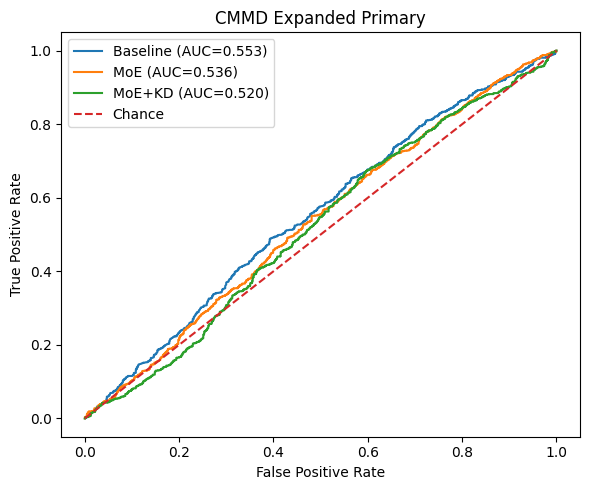

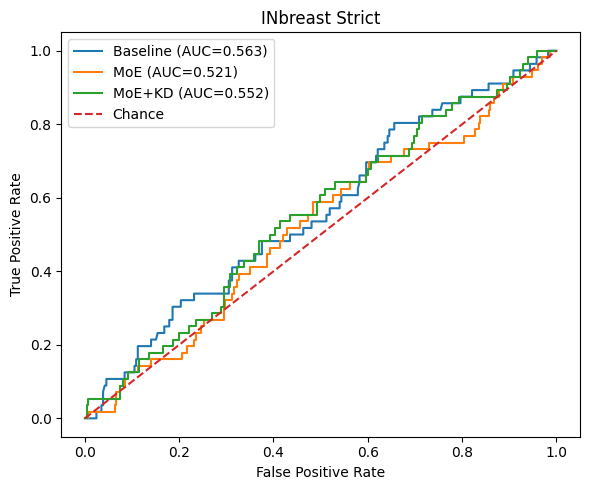

In [79]:
plot_external_roc(
    prediction_df=(
        cmmd_all_predictions
    ),
    cohort_name=(
        "CMMD Expanded Primary"
    ),
    output_path=(
        FIGURE_OUTPUT_DIR
        / "cmmd_primary_roc_curve.png"
    ),
)


plot_external_roc(
    prediction_df=(
        inbreast_strict_predictions
    ),
    cohort_name=(
        "INbreast Strict"
    ),
    output_path=(
        FIGURE_OUTPUT_DIR
        / "inbreast_strict_roc_curve.png"
    ),
)

### **Precision–Recall Curves**

In [80]:
from sklearn.metrics import (
    precision_recall_curve,
)

In [81]:
def plot_external_pr(
    prediction_df,
    cohort_name,
    output_path,
):
    plt.figure(
        figsize=(
            6,
            5,
        )
    )

    reference_df = (
        prediction_df[
            prediction_df[
                "model"
            ]
            == "Baseline"
        ]
    )

    prevalence = float(
        reference_df[
            "label"
        ].mean()
    )


    for model_name in [
        "Baseline",
        "MoE",
        "MoE+KD",
    ]:
        model_df = (
            prediction_df[
                prediction_df[
                    "model"
                ]
                == model_name
            ]
        )

        y_true = (
            model_df[
                "label"
            ].to_numpy()
        )

        y_probability = (
            model_df[
                "probability"
            ].to_numpy()
        )

        precision, recall, _ = (
            precision_recall_curve(
                y_true,
                y_probability,
            )
        )

        ap_value = (
            average_precision_score(
                y_true,
                y_probability,
            )
        )

        plt.plot(
            recall,
            precision,
            label=(
                f"{model_name} "
                f"(AP={ap_value:.3f})"
            ),
        )


    plt.axhline(
        y=prevalence,
        linestyle="--",
        label=(
            f"Prevalence="
            f"{prevalence:.3f}"
        ),
    )


    plt.xlabel(
        "Recall"
    )

    plt.ylabel(
        "Precision"
    )

    plt.title(
        cohort_name
    )

    plt.legend()

    plt.tight_layout()

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

### **Generate PR Figures**

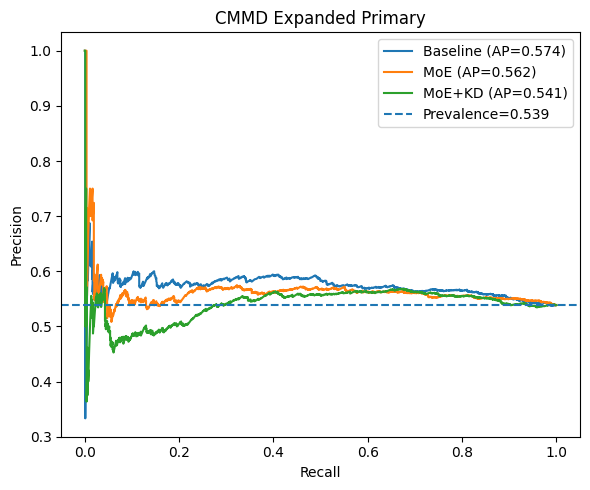

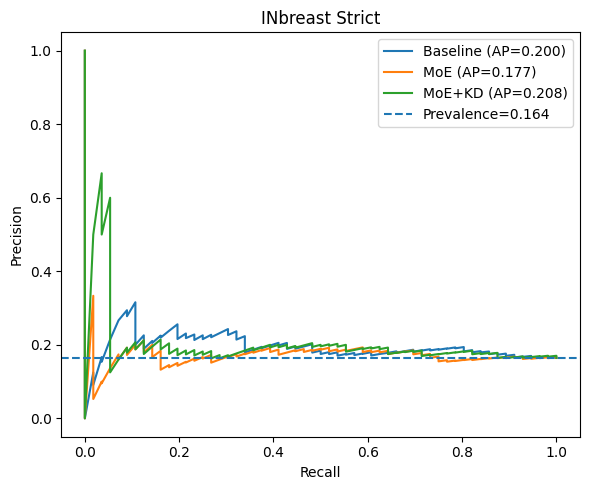

In [82]:
plot_external_pr(
    prediction_df=(
        cmmd_all_predictions
    ),
    cohort_name=(
        "CMMD Expanded Primary"
    ),
    output_path=(
        FIGURE_OUTPUT_DIR
        / "cmmd_primary_pr_curve.png"
    ),
)


plot_external_pr(
    prediction_df=(
        inbreast_strict_predictions
    ),
    cohort_name=(
        "INbreast Strict"
    ),
    output_path=(
        FIGURE_OUTPUT_DIR
        / "inbreast_strict_pr_curve.png"
    ),
)

## **FINAL EXTERNAL VALIDATION SUMMARY**

### **Final Primary Results Table**

In [87]:
final_primary_results = (
    primary_metrics_with_ci[
        [
            "cohort",
            "model",
            "images",
            "patients",
            "roc_auc",
            "roc_auc_ci_lower",
            "roc_auc_ci_upper",
            "average_precision",
            "average_precision_ci_lower",
            "average_precision_ci_upper",
            "threshold",
            "sensitivity",
            "sensitivity_ci_lower",
            "sensitivity_ci_upper",
            "specificity",
            "specificity_ci_lower",
            "specificity_ci_upper",
            "balanced_accuracy",
            "balanced_accuracy_ci_lower",
            "balanced_accuracy_ci_upper",
            "f1",
            "predicted_positive_rate",
        ]
    ]
    .copy()
)


display(
    final_primary_results
    .round(4)
)

,cohort,model,images,patients,roc_auc,roc_auc_ci_lower,roc_auc_ci_upper,average_precision,average_precision_ci_lower,average_precision_ci_upper,...,sensitivity_ci_lower,sensitivity_ci_upper,specificity,specificity_ci_lower,specificity_ci_upper,balanced_accuracy,balanced_accuracy_ci_lower,balanced_accuracy_ci_upper,f1,predicted_positive_rate
0,CMMD Expanded Primary,Baseline,2046,1023,0.5531,0.5254,0.5802,0.5739,0.5357,0.6131,...,0.8363,0.8833,0.2087,0.1800,0.2376,0.5345,0.5154,0.5527,0.6779,0.8284
1,CMMD Expanded Primary,MoE,2046,1023,0.5359,0.5115,0.5607,0.5622,0.5249,0.6004,...,0.9775,0.9927,0.0307,0.0196,0.0431,0.5081,0.5010,0.5149,0.7000,0.9780
2,CMMD Expanded Primary,MoE+KD,2046,1023,0.5199,0.4967,0.5435,0.5407,0.5051,0.5781,...,0.9889,0.9991,0.0095,0.0041,0.0162,0.5020,0.4982,0.5058,0.6996,0.9927
3,INbreast Strict,Baseline,341,100,0.5628,0.4788,0.6483,0.1998,0.1339,0.2980,...,0.5800,0.8104,0.3965,0.3345,0.4552,0.5465,0.4820,0.6086,0.2921,0.6188
4,INbreast Strict,MoE,341,100,0.5206,0.4186,0.6254,0.1766,0.1176,0.2771,...,0.6000,0.8750,0.2035,0.1518,0.2556,0.4768,0.3977,0.5448,0.2585,0.7889
5,INbreast Strict,MoE+KD,341,100,0.5521,0.4458,0.6580,0.2079,0.1315,0.3200,...,0.8333,0.9792,0.1018,0.0667,0.1391,0.5062,0.4638,0.5425,0.2810,0.9003


### **Add Internal AUC and External AUC Drop**

In [84]:
final_primary_results = (
    final_primary_results
    .merge(
        generalization_gap_df[
            [
                "cohort",
                "model",
                "internal_roc_auc",
                "roc_auc_drop",
            ]
        ],
        on=[
            "cohort",
            "model",
        ],
        how="left",
    )
)


display(
    final_primary_results[
        [
            "cohort",
            "model",
            "internal_roc_auc",
            "roc_auc",
            "roc_auc_ci_lower",
            "roc_auc_ci_upper",
            "roc_auc_drop",
            "sensitivity",
            "specificity",
            "balanced_accuracy",
        ]
    ]
    .round(4)
)

,cohort,model,internal_roc_auc,roc_auc,roc_auc_ci_lower,roc_auc_ci_upper,roc_auc_drop,sensitivity,specificity,balanced_accuracy
0,CMMD Expanded Primary,Baseline,0.7716,0.5531,0.5254,0.5802,0.2185,0.8603,0.2087,0.5345
1,CMMD Expanded Primary,MoE,0.7524,0.5359,0.5115,0.5607,0.2165,0.9855,0.0307,0.5081
2,CMMD Expanded Primary,MoE+KD,0.7489,0.5199,0.4967,0.5435,0.2290,0.9946,0.0095,0.5020
3,INbreast Strict,Baseline,0.7716,0.5628,0.4788,0.6483,0.2088,0.6964,0.3965,0.5465
4,INbreast Strict,MoE,0.7524,0.5206,0.4186,0.6254,0.2318,0.7500,0.2035,0.4768
5,INbreast Strict,MoE+KD,0.7489,0.5521,0.4458,0.6580,0.1968,0.9107,0.1018,0.5062


### **Save Final Tables**

In [85]:
FINAL_PRIMARY_RESULTS_PATH = (
    EXTERNAL_OUTPUT_ROOT
    / "final_primary_external_results.csv"
)


FINAL_SENSITIVITY_RESULTS_PATH = (
    EXTERNAL_OUTPUT_ROOT
    / "final_sensitivity_external_results.csv"
)


final_primary_results.to_csv(
    FINAL_PRIMARY_RESULTS_PATH,
    index=False,
)


external_point_metrics[
    external_point_metrics[
        "analysis_role"
    ]
    == "Sensitivity"
].to_csv(
    FINAL_SENSITIVITY_RESULTS_PATH,
    index=False,
)


print(
    "Saved:",
    FINAL_PRIMARY_RESULTS_PATH,
)

print(
    "Saved:",
    FINAL_SENSITIVITY_RESULTS_PATH,
)

Saved: /content/drive/MyDrive/Research/outputs/external_validation/final_primary_external_results.csv
Saved: /content/drive/MyDrive/Research/outputs/external_validation/final_sensitivity_external_results.csv


## **EXTERNAL VALIDATION MANIFEST**

### **Final Manifest**

In [86]:
external_validation_manifest = {
    "analysis_name": (
        "External Validation and "
        "Generalization Analysis"
    ),

    "internal_training_dataset": (
        "CBIS-DDSM"
    ),

    "external_datasets": [
        "CMMD",
        "INbreast",
    ],

    "models": {
        "Baseline": str(
            BASELINE_CHECKPOINT_PATH
        ),
        "MoE": str(
            MOE_CHECKPOINT_PATH
        ),
        "MoE+KD": str(
            KD_CHECKPOINT_PATH
        ),
    },

    "frozen_thresholds": {
        key: float(value)
        for key, value
        in FROZEN_THRESHOLDS.items()
    },

    "threshold_source": (
        "Internal CBIS-DDSM validation only"
    ),

    "external_threshold_optimization": False,

    "external_finetuning": False,

    "external_calibration": False,

    "primary_cohorts": {
        "CMMD": {
            "name": (
                "Expanded lesion-side primary"
            ),
            "images": 2046,
            "patients": 1023,
        },
        "INbreast": {
            "name": (
                "Strict breast-time-point "
                "consistent"
            ),
            "images": 341,
            "patients": 100,
        },
    },

    "sensitivity_cohorts": {
        "CMMD": {
            "name": (
                "Strict two-image"
            ),
            "images": 1886,
            "patients": 943,
        },
        "INbreast": {
            "name": (
                "Broad breast-time-point "
                "consistent"
            ),
            "images": 383,
            "patients": 103,
        },
    },

    "student_preprocessing": {
        "height": 512,
        "width": 320,
        "resize_interpolation": (
            "bilinear"
        ),
        "per_image_min_max_scaling": True,
        "imagenet_normalization": True,
    },

    "evaluation_unit": (
        "image-level"
    ),

    "uncertainty_method": (
        "patient-cluster bootstrap"
    ),

    "bootstrap_replicates": (
        int(
            BOOTSTRAP_REPLICATES
        )
    ),

    "bootstrap_seed": (
        int(
            BOOTSTRAP_SEED
        )
    ),

    "bootstrap_ci": (
        "percentile 95%"
    ),

    "primary_generalization_metric": (
        "ROC-AUC"
    ),

    "average_precision_note": (
        "Average Precision is reported "
        "within each cohort and is not "
        "used as the primary cross-dataset "
        "generalization-gap measure because "
        "AP depends on class prevalence."
    ),

    "paired_bootstrap_note": (
        "Pairwise model comparisons use "
        "the same resampled patient clusters "
        "within each bootstrap replicate."
    ),

    "output_paths": {
        "primary_results": str(
            FINAL_PRIMARY_RESULTS_PATH
        ),
        "sensitivity_results": str(
            FINAL_SENSITIVITY_RESULTS_PATH
        ),
        "bootstrap_ci": str(
            PRIMARY_BOOTSTRAP_CI_PATH
        ),
        "paired_differences": str(
            PAIRED_BOOTSTRAP_PATH
        ),
        "generalization_gap": str(
            GENERALIZATION_GAP_PATH
        ),
        "routing_summary": str(
            ROUTING_OUTPUT_DIR
            / "external_routing_summary.csv"
        ),
    },
}


EXTERNAL_VALIDATION_MANIFEST_PATH = (
    EXTERNAL_OUTPUT_ROOT
    / "external_validation_manifest.json"
)


with open(
    EXTERNAL_VALIDATION_MANIFEST_PATH,
    "w",
) as file:
    json.dump(
        external_validation_manifest,
        file,
        indent=4,
    )


print(
    json.dumps(
        external_validation_manifest,
        indent=4,
    )
)


print(
    "\nSaved:",
    EXTERNAL_VALIDATION_MANIFEST_PATH,
)

{
    "analysis_name": "External Validation and Generalization Analysis",
    "internal_training_dataset": "CBIS-DDSM",
    "external_datasets": [
        "CMMD",
        "INbreast"
    ],
    "models": {
        "Baseline": "/content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_baseline/checkpoints/mobilenetv3_small_baseline_best.pt",
        "MoE": "/content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe/checkpoints/mobilenetv3_small_sparse_top2_moe_best.pt",
        "MoE+KD": "/content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe_kd/checkpoints/mobilenetv3_small_sparse_top2_moe_kd_best.pt"
    },
    "frozen_thresholds": {
        "Baseline": 0.5166015625,
        "MoE": 0.3496335447,
        "MoE+KD": 0.2529684305
    },
    "threshold_source": "Internal CBIS-DDSM validation only",
    "external_threshold_optimization": false,
    "external_finetuning": false,
    "external_calibration": false,
    "primary_cohorts":

## **FINAL VALIDATION AND COMPLETION**

### **Final Notebook Validation**

In [88]:
final_validation_checks = {
    "cmmd_primary_images": (
        len(
            cmmd_all_predictions[
                cmmd_all_predictions[
                    "model"
                ]
                == "Baseline"
            ]
        )
        == 2046
    ),

    "inbreast_strict_images": (
        len(
            inbreast_strict_predictions[
                inbreast_strict_predictions[
                    "model"
                ]
                == "Baseline"
            ]
        )
        == 341
    ),

    "three_models_present": (
        set(
            cmmd_all_predictions[
                "model"
            ].unique()
        )
        == {
            "Baseline",
            "MoE",
            "MoE+KD",
        }
    ),

    "all_bootstrap_replicates_valid_cmmd": (
        cmmd_primary_bootstrap[
            "bootstrap_index"
        ].nunique()
        == 2000
    ),

    "all_bootstrap_replicates_valid_inbreast": (
        inbreast_strict_bootstrap[
            "bootstrap_index"
        ].nunique()
        == 2000
    ),

    "external_threshold_optimization_disabled": (
        external_validation_manifest[
            "external_threshold_optimization"
        ]
        is False
    ),

    "external_finetuning_disabled": (
        external_validation_manifest[
            "external_finetuning"
        ]
        is False
    ),

    "external_calibration_disabled": (
        external_validation_manifest[
            "external_calibration"
        ]
        is False
    ),
}


final_validation_dataframe = (
    pd.DataFrame(
        [
            {
                "check": key,
                "passed": value,
            }
            for key, value
            in final_validation_checks.items()
        ]
    )
)


display(
    final_validation_dataframe
)


assert all(
    final_validation_checks.values()
)


print(
    "\nAll Notebook 08 final "
    "validation checks passed."
)

,check,passed
0,cmmd_primary_images,True
1,inbreast_strict_images,True
2,three_models_present,True
3,all_bootstrap_replicates_valid_cmmd,True
4,all_bootstrap_replicates_valid_inbreast,True
5,external_threshold_optimization_disabled,True
6,external_finetuning_disabled,True
7,external_calibration_disabled,True



All Notebook 08 final validation checks passed.


### **Final External Validation Summary**

In [89]:
print(
    "=" * 72
)

print(
    "NOTEBOOK 08 — EXTERNAL VALIDATION SUMMARY"
)

print(
    "=" * 72
)

print(
    "\nTraining/development dataset:"
)

print(
    "  CBIS-DDSM"
)

print(
    "\nPrimary external cohorts:"
)

print(
    "  CMMD Expanded Primary : "
    "2046 images / 1023 patients"
)

print(
    "  INbreast Strict       : "
    "341 images / 100 patients"
)

print(
    "\nModels:"
)

print(
    "  MobileNetV3-Small Baseline"
)

print(
    "  Sparse Top-2 MoE"
)

print(
    "  Sparse Top-2 MoE + KD"
)

print(
    "\nExternal evaluation policy:"
)

print(
    "  No retraining"
)

print(
    "  No fine-tuning"
)

print(
    "  No threshold optimization"
)

print(
    "  No external calibration"
)

print(
    "\nUncertainty estimation:"
)

print(
    "  2000-replicate "
    "patient-cluster bootstrap"
)

print(
    "\nPrimary external ROC-AUC:"
)


for _, row in (
    final_primary_results
    .iterrows()
):
    print(
        f"  {row['cohort']:22s} | "
        f"{row['model']:8s} | "
        f"AUC="
        f"{row['roc_auc']:.4f} "
        f"("
        f"{row['roc_auc_ci_lower']:.4f}"
        f"–"
        f"{row['roc_auc_ci_upper']:.4f}"
        f")"
    )


print(
    "\nNotebook 08 completed successfully."
)

NOTEBOOK 08 — EXTERNAL VALIDATION SUMMARY

Training/development dataset:
  CBIS-DDSM

Primary external cohorts:
  CMMD Expanded Primary : 2046 images / 1023 patients
  INbreast Strict       : 341 images / 100 patients

Models:
  MobileNetV3-Small Baseline
  Sparse Top-2 MoE
  Sparse Top-2 MoE + KD

External evaluation policy:
  No retraining
  No fine-tuning
  No threshold optimization
  No external calibration

Uncertainty estimation:
  2000-replicate patient-cluster bootstrap

Primary external ROC-AUC:
  CMMD Expanded Primary  | Baseline | AUC=0.5531 (0.5254–0.5802)
  CMMD Expanded Primary  | MoE      | AUC=0.5359 (0.5115–0.5607)
  CMMD Expanded Primary  | MoE+KD   | AUC=0.5199 (0.4967–0.5435)
  INbreast Strict        | Baseline | AUC=0.5628 (0.4788–0.6483)
  INbreast Strict        | MoE      | AUC=0.5206 (0.4186–0.6254)
  INbreast Strict        | MoE+KD   | AUC=0.5521 (0.4458–0.6580)

Notebook 08 completed successfully.
